# RailInsight — Phase 3: Exploratory Data Analysis

**Analytical Question:**
> What patterns, trends, relationships, and operational factors are associated with train delays?

**Dataset:** `data/processed/train_cleaned.parquet` (1,500,000 rows × 45 columns)

**Date Range:** 2018-01-01 to 2024-12-30

**Framework:** Business Question → Metric → Analysis → Visualization → Finding

**Language convention:** *associated with*, *suggests*, *observed pattern*, *may indicate* — NOT *causes*.

**Figures saved to:** `../report/figures/eda/`

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
})
sns.set_palette('tab10')

FIG_DIR = os.path.join('..', 'report', 'figures', 'eda')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, bbox_inches='tight')
    print(f'  -> Saved: {path}')

# Reusable flag summary: group by binary flag, compute delay stats
def flag_summary(flag_col):
    grp = (
        train.groupby(flag_col, observed=True)
        .agg(
            total=('journey_id', 'count'),
            delayed=('is_delayed', 'sum'),
            avg_delay=('delay_minutes', 'mean'),
            median_delay=('delay_minutes', 'median'),
        )
        .reset_index()
    )
    grp['delay_rate_pct'] = (grp['delayed'] / grp['total'] * 100).round(2)
    return grp

print('Imports OK. Figure output:', os.path.abspath(FIG_DIR))

Imports OK. Figure output: D:\Project\RailInsight\report\figures\eda


In [2]:
train = pd.read_parquet('../data/processed/train_cleaned.parquet')
print(f'Loaded: {train.shape[0]:,} rows x {train.shape[1]} columns')

Loaded: 1,500,000 rows x 45 columns


---
## Section 1 — Post-Cleaning Dataset Overview

**Business Question:** Is the cleaned dataset ready for analysis? Any residual quality issues?

**Metrics:** Shape, dtypes, missing values, duplicates, zero-variance columns

In [3]:
print('=== Shape ===')
print(f'Rows: {train.shape[0]:,}  |  Columns: {train.shape[1]}')
print()
print('=== Column List ===')
print(list(train.columns))

=== Shape ===
Rows: 1,500,000  |  Columns: 45

=== Column List ===
['journey_id', 'train_number', 'train_type', 'departure_date', 'year', 'month', 'day_of_week', 'departure_hour', 'is_weekend', 'is_night_departure', 'is_peak_hour', 'is_festival_season', 'season', 'zone', 'zone_abbr', 'source_station_category', 'destination_station_category', 'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'track_doubled', 'is_hdn_route', 'traction_type', 'is_electrified', 'psr_count', 'is_circular_route', 'is_monsoon_season', 'is_fog_risk', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index', 'season_severity_score', 'loco_age_years', 'coach_age_years', 'has_lhb_coaches', 'is_rake_shared', 'maintenance_score', 'seat_utilisation_pct', 'is_overloaded', 'late_incoming_rake', 'is_special_train', 'route_historical_ontime_pct', 'primary_delay_cause', 'delay_minutes', 'is_delayed']


In [4]:
print('=== Data Types ===')
print(train.dtypes.to_string())

=== Data Types ===
journey_id                                 str
train_number                               str
train_type                            category
departure_date                  datetime64[us]
year                                     int64
month                                    int64
day_of_week                              int64
departure_hour                           int64
is_weekend                               int64
is_night_departure                       int64
is_peak_hour                             int64
is_festival_season                       int64
season                                category
zone                                  category
zone_abbr                             category
source_station_category               category
destination_station_category          category
distance_km                              int64
num_scheduled_stops                      int64
scheduled_travel_hours                 float64
track_doubled                            

In [5]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(4)
mv = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
mv = mv[mv['missing_count'] > 0]
print('=== Missing Values ===')
if mv.empty:
    print('No missing values detected — dataset is complete.')
else:
    print(mv)

=== Missing Values ===
No missing values detected — dataset is complete.


In [6]:
dup_count = train.duplicated().sum()
unique_j  = train['journey_id'].nunique()
print(f'Duplicate rows : {dup_count}')
print(f'Unique journey_id: {unique_j:,}')
print(f'Matches row count: {unique_j == len(train)}')

Duplicate rows : 0
Unique journey_id: 1,500,000
Matches row count: True


In [7]:
print('=== Numerical Summary ===')
train.select_dtypes(include='number').describe().T.round(3)

=== Numerical Summary ===


,count,mean,std,min,25%,50%,75%,max
year,1500000.0,2021.003,2.000,2018.00,2019.00,2021.00,2023.00,2024.00
month,1500000.0,6.518,3.448,1.00,4.00,7.00,10.00,12.00
day_of_week,1500000.0,3.001,2.002,0.00,1.00,3.00,5.00,6.00
departure_hour,1500000.0,13.113,5.832,0.00,8.00,14.00,18.00,23.00
is_weekend,1500000.0,0.286,0.452,0.00,0.00,0.00,1.00,1.00
is_night_departure,1500000.0,0.101,0.301,0.00,0.00,0.00,0.00,1.00
is_peak_hour,1500000.0,0.468,0.499,0.00,0.00,0.00,1.00,1.00
is_festival_season,1500000.0,0.180,0.384,0.00,0.00,0.00,0.00,1.00
distance_km,1500000.0,609.967,371.255,50.00,342.00,544.00,792.00,3000.00
num_scheduled_stops,1500000.0,12.000,3.463,1.00,10.00,12.00,14.00,34.00


In [8]:
cat_cols = train.select_dtypes(include=['object', 'category']).columns
print('=== Categorical Columns ===')
for col in cat_cols:
    n_unique = train[col].nunique()
    top = train[col].value_counts().index[0]
    print(f'  {col:40s}  unique={n_unique:4d}   top="{top}"')

=== Categorical Columns ===


  journey_id                                unique=1500000   top="IR01717809"
  train_number                              unique=6293   top="12805"
  train_type                                unique=  15   top="Mail/Express"
  season                                    unique=   6   top="Monsoon"
  zone                                      unique=  16   top="North Eastern Railway (NER)"
  zone_abbr                                 unique=  16   top="NER"
  source_station_category                   unique=   6   top="C"
  destination_station_category              unique=   6   top="C"
  traction_type                             unique=   3   top="Electric (25kV AC)"


  primary_delay_cause                       unique=  15   top="On Time"


In [9]:
num_cols = train.select_dtypes(include='number').columns
zero_var = [c for c in num_cols if train[c].nunique() == 1]
print('=== Zero-Variance (Constant) Columns ===')
if zero_var:
    for c in zero_var:
        print(f'  {c}: constant value = {train[c].iloc[0]}')
else:
    print('None found')
print()
print('--- is_overloaded value_counts ---')
print(train['is_overloaded'].value_counts())
print()
print(
    'FINDING (Sec 1): is_overloaded = 0 for ALL 1,500,000 records.\n'
    'Zero variance means it CANNOT distinguish any journey from another.\n'
    'It must be excluded from all analytical and modelling phases.'
)

=== Zero-Variance (Constant) Columns ===
  is_overloaded: constant value = 0

--- is_overloaded value_counts ---
is_overloaded
0    1500000
Name: count, dtype: int64

FINDING (Sec 1): is_overloaded = 0 for ALL 1,500,000 records.
Zero variance means it CANNOT distinguish any journey from another.
It must be excluded from all analytical and modelling phases.


---
## Section 2 — Target / Delay Overview

**Business Question:** How common are train delays, and how severe are they?

**Metrics:** Delay count/rate, delay_minutes statistics (all journeys vs delayed-only)

In [10]:
total = len(train)
delay_counts  = train['is_delayed'].value_counts().sort_index()
delayed_count = int(delay_counts.get(1, 0))
ontime_count  = int(delay_counts.get(0, 0))
delayed_pct   = delayed_count / total * 100
ontime_pct    = ontime_count  / total * 100
delayed = train[train['is_delayed'] == 1]  # subset used throughout notebook

print(f'Total journeys        : {total:,}')
print(f'Delayed  (is_delayed=1): {delayed_count:,}  ({delayed_pct:.2f}%)')
print(f'On-time  (is_delayed=0): {ontime_count:,}  ({ontime_pct:.2f}%)')

Total journeys        : 1,500,000
Delayed  (is_delayed=1): 1,078,329  (71.89%)
On-time  (is_delayed=0): 421,671  (28.11%)


  -> Saved: ..\report\figures\eda\02_delay_status_bar.png


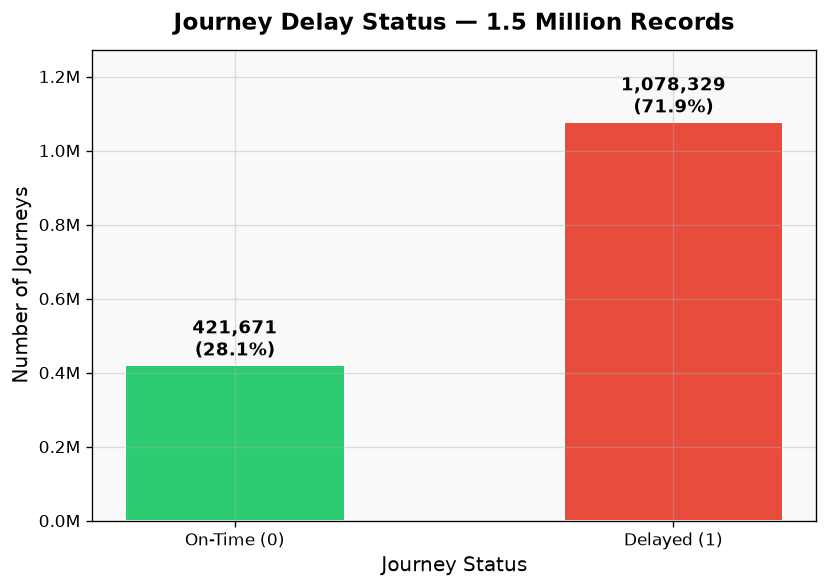

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['On-Time (0)', 'Delayed (1)']
values = [ontime_count, delayed_count]
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
for bar, val, pct in zip(bars, values, [ontime_pct, delayed_pct]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8000,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )
ax.set_title('Journey Delay Status — 1.5 Million Records', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Journey Status')
ax.set_ylabel('Number of Journeys')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_ylim(0, max(values) * 1.18)
plt.tight_layout()
savefig('02_delay_status_bar.png')
plt.show()

In [12]:
print('=== delay_minutes — All journeys ===')
print(train['delay_minutes'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))
print()
print(f'=== delay_minutes — Delayed only ({len(delayed):,} records) ===')
print(delayed['delay_minutes'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))
print()
print(
    'NOTE: Include all-journeys histogram (bimodal: spike at 0 + hump at 100-150 min)\n'
    'and delayed-only histogram (roughly bell-shaped around 127 min median).'
)

=== delay_minutes — All journeys ===
count    1500000.00
mean          97.73
std           66.17
min            0.00
25%           13.00
50%          111.00
75%          140.00
max          579.00
Name: delay_minutes, dtype: float64

=== delay_minutes — Delayed only (1,078,329 records) ===
count    1078329.00
mean         133.21
std           40.08
min           37.00
25%          106.00
50%          127.00
75%          152.00
max          579.00
Name: delay_minutes, dtype: float64

NOTE: Include all-journeys histogram (bimodal: spike at 0 + hump at 100-150 min)
and delayed-only histogram (roughly bell-shaped around 127 min median).


  -> Saved: ..\report\figures\eda\02_delay_minutes_histogram.png


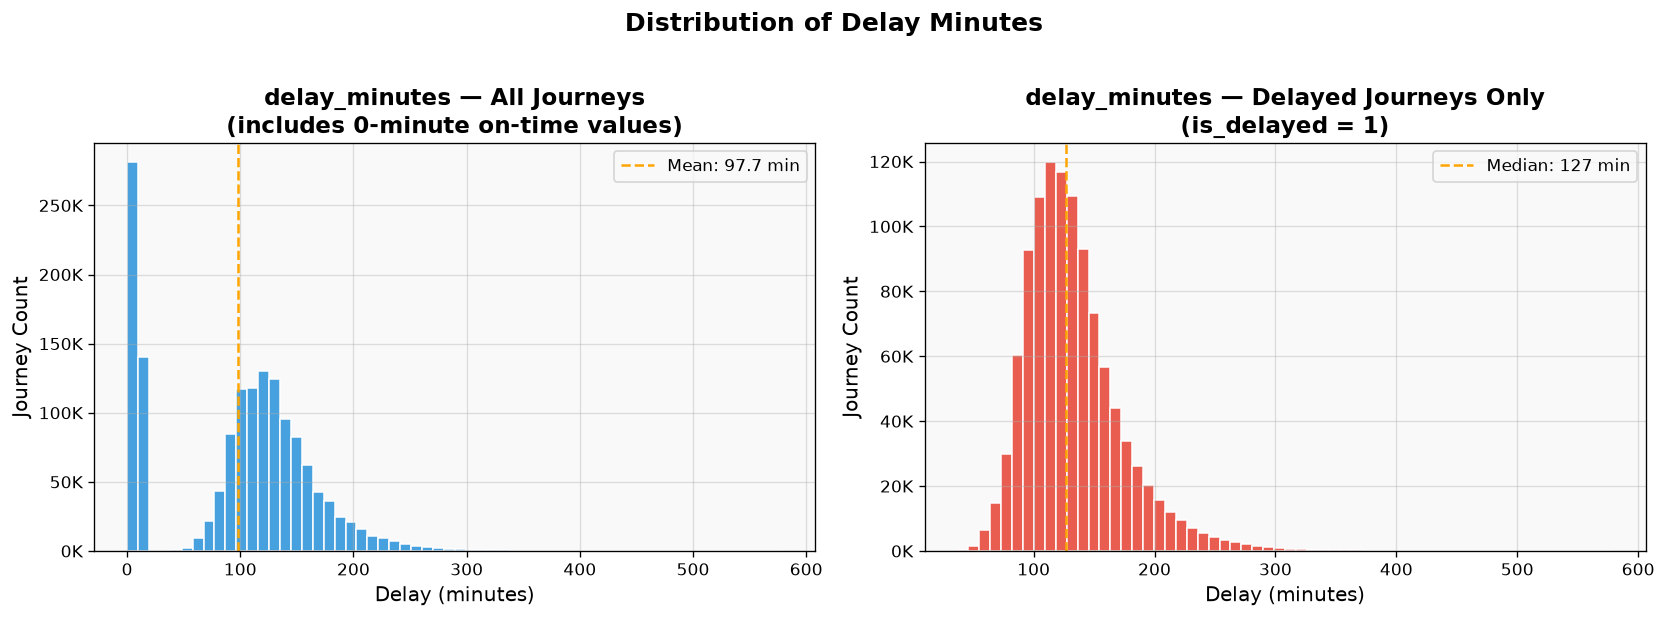

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all journeys
axes[0].hist(train['delay_minutes'], bins=60, color='#3498db', edgecolor='white', alpha=0.9)
axes[0].set_title('delay_minutes — All Journeys\n(includes 0-minute on-time values)', fontweight='bold')
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Journey Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].axvline(
    train['delay_minutes'].mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f"Mean: {train['delay_minutes'].mean():.1f} min"
)
axes[0].legend()

# Right: delayed only
axes[1].hist(delayed['delay_minutes'], bins=60, color='#e74c3c', edgecolor='white', alpha=0.9)
axes[1].set_title('delay_minutes — Delayed Journeys Only\n(is_delayed = 1)', fontweight='bold')
axes[1].set_xlabel('Delay (minutes)')
axes[1].set_ylabel('Journey Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].axvline(
    delayed['delay_minutes'].median(), color='orange', linestyle='--', linewidth=1.5,
    label=f"Median: {delayed['delay_minutes'].median():.0f} min"
)
axes[1].legend()

plt.suptitle('Distribution of Delay Minutes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('02_delay_minutes_histogram.png')
plt.show()

  -> Saved: ..\report\figures\eda\02_delay_minutes_boxplot.png


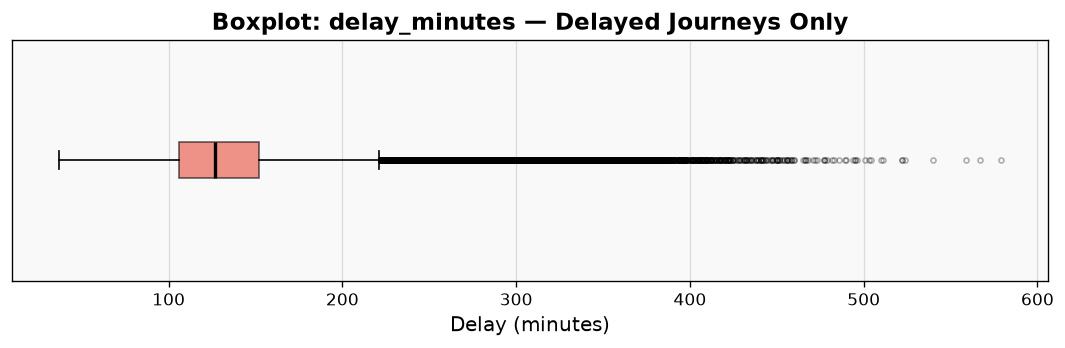

In [14]:
# Boxplot for extreme delay context
fig, ax = plt.subplots(figsize=(9, 3))
ax.boxplot(
    delayed['delay_minutes'], vert=False, patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', color='#c0392b', alpha=0.3, markersize=3),
)
ax.set_title('Boxplot: delay_minutes — Delayed Journeys Only', fontweight='bold')
ax.set_xlabel('Delay (minutes)')
ax.set_yticks([])
plt.tight_layout()
savefig('02_delay_minutes_boxplot.png')
plt.show()

---
## Section 3 — Day-of-Week Analysis

**Business Question:** Are certain days of the week associated with higher delay rates?

**Key Rule:** Compare delay RATE (%), not raw counts, since daily volumes may differ.

In [15]:
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

dow = (
    train.groupby('day_of_week', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
    .sort_values('day_of_week')
)
dow['delay_rate_pct'] = (dow['delayed'] / dow['total'] * 100).round(2)
dow['day_name'] = dow['day_of_week'].map(day_map)

print('=== Day-of-Week Delay Summary ===')
print(dow[['day_name', 'total', 'delayed', 'delay_rate_pct', 'avg_delay', 'median_delay']].to_string(index=False))

=== Day-of-Week Delay Summary ===
 day_name  total  delayed  delay_rate_pct  avg_delay  median_delay
   Monday 215401   155276           72.09  98.027966         111.0
  Tuesday 213377   153792           72.08  97.857899         110.0
Wednesday 213706   154149           72.13  97.946660         111.0
 Thursday 214254   154268           72.00  97.874168         111.0
   Friday 213806   154321           72.18  97.956961         111.0
 Saturday 214547   153199           71.41  97.362079         110.0
   Sunday 214909   153324           71.34  97.075036         110.0


  -> Saved: ..\report\figures\eda\03_day_of_week_delay.png


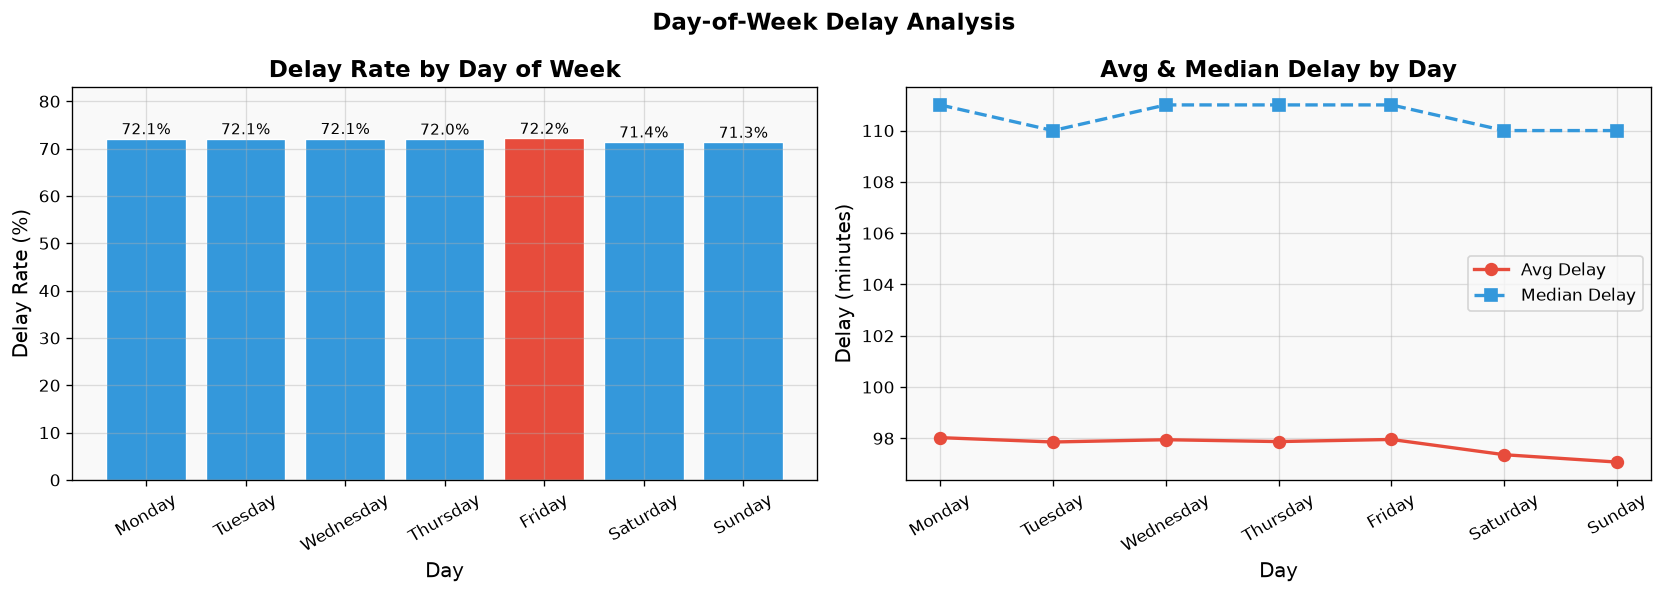

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay rate bar chart
palette_dow = ['#e74c3c' if r == dow['delay_rate_pct'].max() else '#3498db'
               for r in dow['delay_rate_pct']]
bars = axes[0].bar(dow['day_name'], dow['delay_rate_pct'],
                   color=palette_dow, edgecolor='white', linewidth=0.8)
axes[0].set_title('Delay Rate by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_ylim(0, dow['delay_rate_pct'].max() * 1.15)
for bar, v in zip(bars, dow['delay_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Avg + Median line chart
axes[1].plot(dow['day_name'], dow['avg_delay'], marker='o', color='#e74c3c',
             linewidth=2, markersize=7, label='Avg Delay')
axes[1].plot(dow['day_name'], dow['median_delay'], marker='s', color='#3498db',
             linewidth=2, linestyle='--', markersize=7, label='Median Delay')
axes[1].set_title('Avg & Median Delay by Day', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Delay (minutes)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Day-of-Week Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('03_day_of_week_delay.png')
plt.show()

---
## Section 4 — Month and Seasonal Analysis

**Business Question:** Are delays seasonal? Do monsoon or festival periods show higher rates?

**Important:** Month order is preserved chronologically (Jan→Dec), not alphabetically.

In [17]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = (
    train.groupby('month', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
    .sort_values('month')  # chronological, NOT alphabetical
)
monthly['delay_rate_pct'] = (monthly['delayed'] / monthly['total'] * 100).round(2)
monthly['month_name'] = monthly['month'].map(month_map)

print('=== Monthly Delay Summary ===')
print(monthly[['month_name','total','delayed','delay_rate_pct','avg_delay','median_delay']].to_string(index=False))

=== Monthly Delay Summary ===
month_name  total  delayed  delay_rate_pct  avg_delay  median_delay
       Jan 127871   102539           80.19 110.816886         119.0
       Feb 116159    90084           77.55 106.117382         116.0
       Mar 127299    60613           47.61  63.882497          14.0
       Apr 123179    61029           49.54  66.373668          14.0
       May 127469    68874           54.03  72.502750          83.0
       Jun 123017   113400           92.18 125.345619         125.0
       Jul 127373   119523           93.84 128.676902         127.0
       Aug 127614   120508           94.43 130.008541         128.0
       Sep 122794   111421           90.74 122.467230         124.0
       Oct 127778    74546           58.34  78.518290          92.0
       Nov 122704    62097           50.61  67.992339          66.0
       Dec 126743    93695           73.93 100.449484         112.0


  -> Saved: ..\report\figures\eda\04_monthly_delay.png


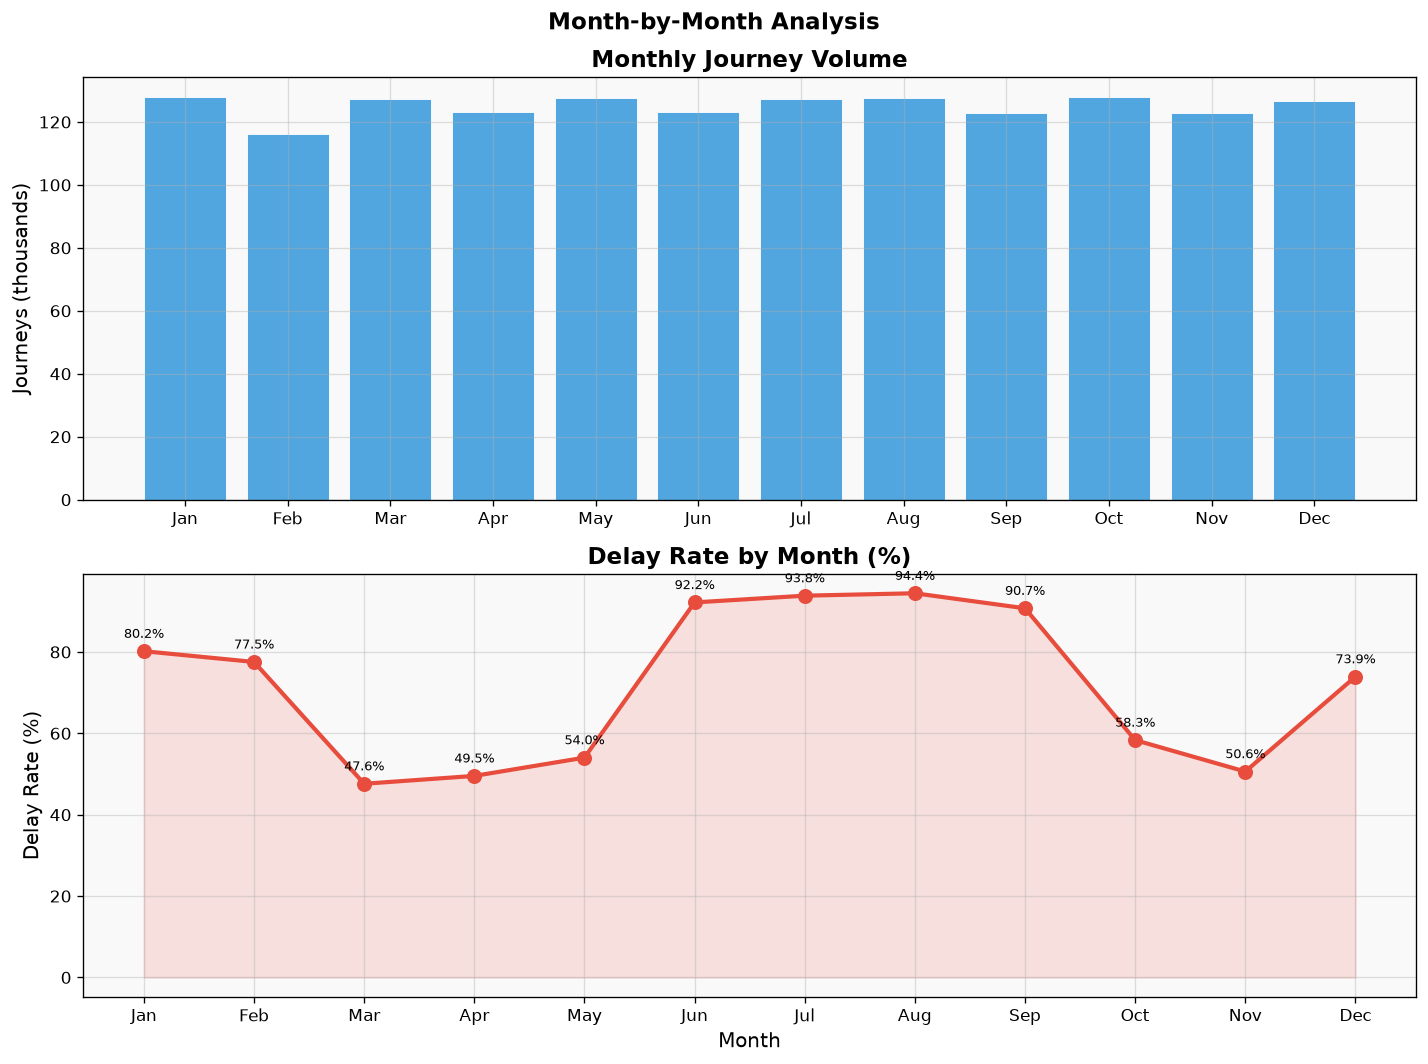

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Volume bar
axes[0].bar(monthly['month_name'], monthly['total'] / 1000,
            color='#3498db', edgecolor='white', linewidth=0.6, alpha=0.85)
axes[0].set_title('Monthly Journey Volume', fontweight='bold')
axes[0].set_ylabel('Journeys (thousands)')
axes[0].set_xlabel('')

# Delay rate line
x_idx = range(len(monthly))
axes[1].plot(x_idx, monthly['delay_rate_pct'], marker='o',
             color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(x_idx, monthly['delay_rate_pct'], alpha=0.15, color='#e74c3c')
axes[1].set_title('Delay Rate by Month (%)', fontweight='bold')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_xlabel('Month')
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(monthly['month_name'])
for i, (x, y) in enumerate(zip(x_idx, monthly['delay_rate_pct'])):
    axes[1].annotate(f'{y:.1f}%', (x, y),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)

plt.suptitle('Month-by-Month Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('04_monthly_delay.png')
plt.show()

In [19]:
# Season aggregation
seasonal = (
    train.groupby('season', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
        avg_severity=('season_severity_score', 'mean'),
    )
    .reset_index()
)
seasonal['delay_rate_pct'] = (seasonal['delayed'] / seasonal['total'] * 100).round(2)
seasonal = seasonal.sort_values('delay_rate_pct', ascending=False)

print('=== Season Summary ===')
print(seasonal.to_string(index=False))
print()
print('=== is_monsoon_season ===')
print(flag_summary('is_monsoon_season').to_string(index=False))
print()
print('=== is_festival_season ===')
print(flag_summary('is_festival_season').to_string(index=False))

=== Season Summary ===
      season  total  delayed  avg_delay  median_delay  avg_severity  delay_rate_pct
     Monsoon 500798   464852 126.675338         126.0      0.845838           92.82
  Winter/Fog 370773   286318 105.800649         116.0      0.716764           77.22
Post-Monsoon 127778    74546  78.518290          92.0      0.420000           58.34
 Pre-Monsoon 127469    68874  72.502750          83.0      0.350000           54.03
      Autumn 122704    62097  67.992339          66.0      0.300000           50.61
      Summer 250478   121642  65.107594          14.0      0.264753           48.56

=== is_monsoon_season ===
 is_monsoon_season  total  delayed  avg_delay  median_delay  delay_rate_pct
                 0 999202   613477  83.220149          98.0           61.40
                 1 500798   464852 126.675338         126.0           92.82

=== is_festival_season ===


 is_festival_season   total  delayed  avg_delay  median_delay  delay_rate_pct
                  0 1229846   871464  96.587343         110.0           70.86
                  1  270154   206865 102.922548         113.0           76.57


  -> Saved: ..\report\figures\eda\04_seasonal_delay.png


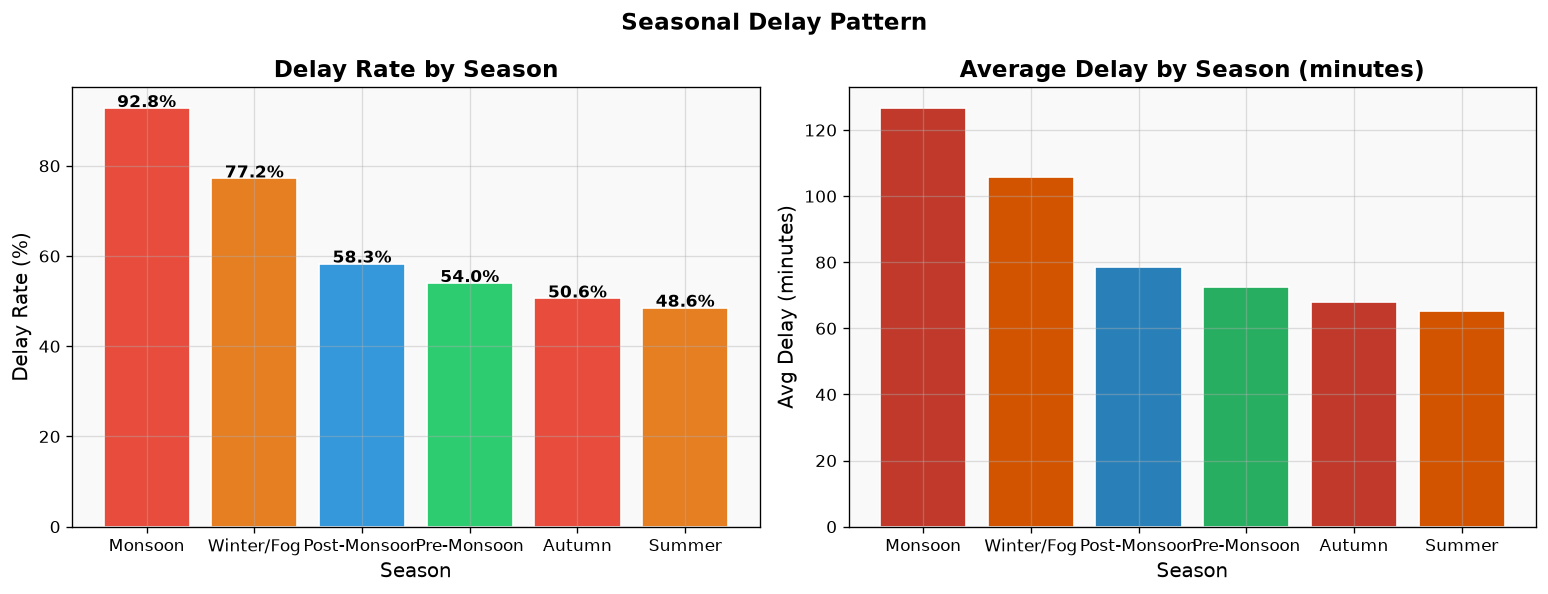

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_s = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71'][:len(seasonal)]
axes[0].bar(seasonal['season'], seasonal['delay_rate_pct'],
            color=colors_s, edgecolor='white')
axes[0].set_title('Delay Rate by Season', fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Delay Rate (%)')
for bar, v in zip(axes[0].patches, seasonal['delay_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(seasonal['season'], seasonal['avg_delay'],
            color=['#c0392b','#d35400','#2980b9','#27ae60'][:len(seasonal)],
            edgecolor='white')
axes[1].set_title('Average Delay by Season (minutes)', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Delay (minutes)')

plt.suptitle('Seasonal Delay Pattern', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('04_seasonal_delay.png')
plt.show()

---
## Section 5 — Yearly Trend Analysis

**Business Question:** Has delay behaviour improved or worsened from 2018 to 2024?

**Key Distinction:** Volume, rate, and severity are three DIFFERENT metrics — read all three.

In [21]:
yearly = (
    train.groupby('year', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
    .sort_values('year')
)
yearly['delay_rate_pct'] = (yearly['delayed'] / yearly['total'] * 100).round(2)

print('=== Yearly Delay Summary (2018-2024) ===')
print(yearly.to_string(index=False))

=== Yearly Delay Summary (2018-2024) ===
 year  total  delayed  avg_delay  median_delay  delay_rate_pct
 2018 213861   153599  97.659999         111.0           71.82
 2019 214095   154342  97.941278         111.0           72.09
 2020 214236   153971  97.591367         111.0           71.87
 2021 213670   153297  97.542818         110.0           71.74
 2022 214353   154242  97.861957         111.0           71.96
 2023 215538   154813  97.796611         110.0           71.83
 2024 214247   154065  97.703324         111.0           71.91


  -> Saved: ..\report\figures\eda\05_yearly_trends.png


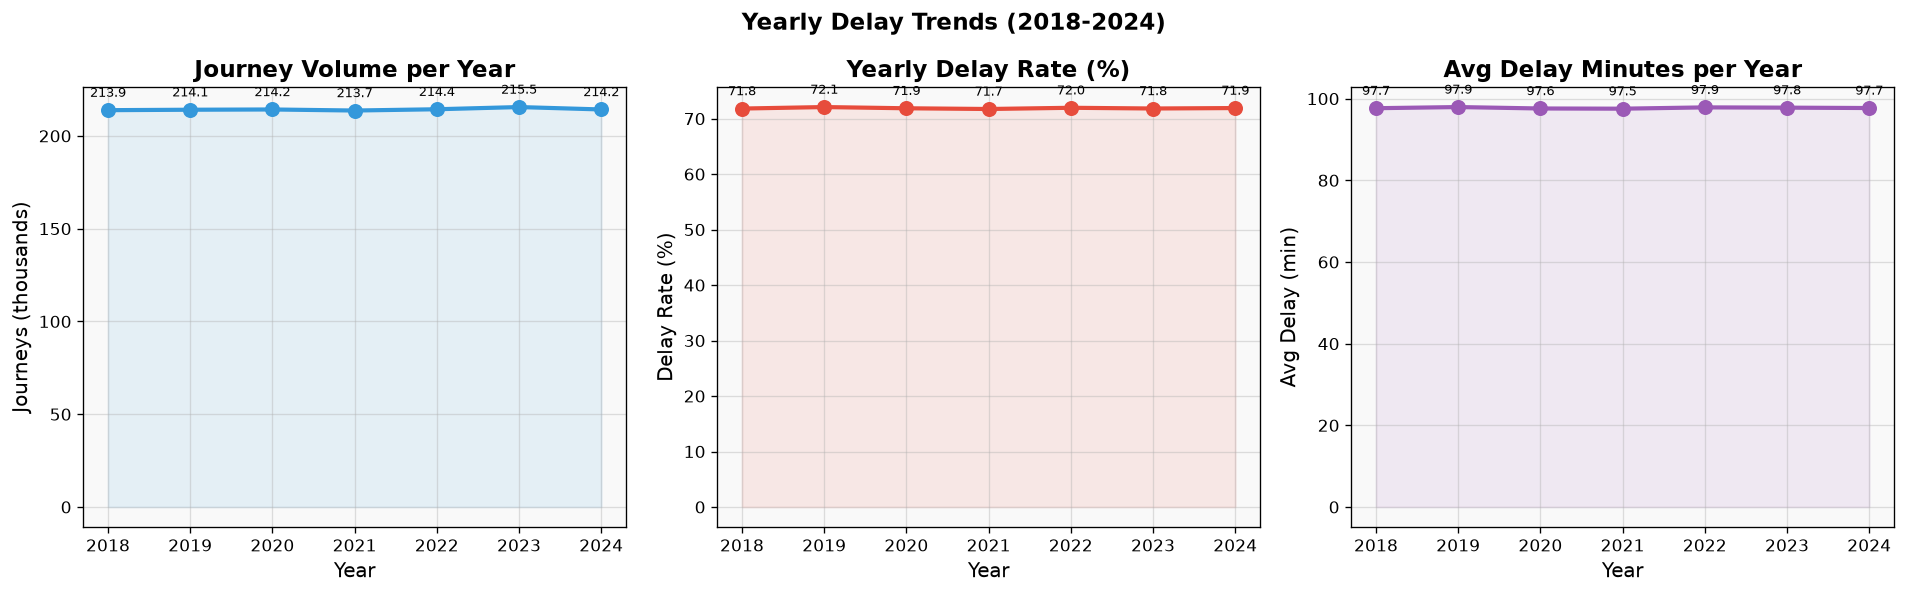

NOTE: Delay rate (%) adjusts for traffic volume. Use it as the primary trend metric.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def line_chart(ax, x, y, title, ylabel, color):
    ax.plot(x, y, marker='o', color=color, linewidth=2.5, markersize=8)
    ax.fill_between(x, y, alpha=0.1, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    for xi, yi in zip(x, y):
        ax.annotate(f'{yi:.1f}', (xi, yi),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8)

line_chart(axes[0], yearly['year'], yearly['total'] / 1000,
           'Journey Volume per Year', 'Journeys (thousands)', '#3498db')
line_chart(axes[1], yearly['year'], yearly['delay_rate_pct'],
           'Yearly Delay Rate (%)', 'Delay Rate (%)', '#e74c3c')
line_chart(axes[2], yearly['year'], yearly['avg_delay'],
           'Avg Delay Minutes per Year', 'Avg Delay (min)', '#9b59b6')

plt.suptitle('Yearly Delay Trends (2018-2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('05_yearly_trends.png')
plt.show()

print('NOTE: Delay rate (%) adjusts for traffic volume. Use it as the primary trend metric.')

---
## Section 6 — Departure Time Analysis

**Business Question:** Are delays associated with departure hour, peak hours, or night departures?

**Caution:** Do not automatically conclude that peak hours CAUSE delays — association only.

In [23]:
hourly = (
    train.groupby('departure_hour', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
    )
    .reset_index()
    .sort_values('departure_hour')
)
hourly['delay_rate_pct'] = (hourly['delayed'] / hourly['total'] * 100).round(2)

print('=== Hourly Delay Rate (departure_hour) ===')
print(hourly[['departure_hour','total','delayed','delay_rate_pct','avg_delay']].to_string(index=False))

=== Hourly Delay Rate (departure_hour) ===
 departure_hour  total  delayed  delay_rate_pct  avg_delay
              0  22960    17611           76.70 103.623998
              1  13826    10544           76.26 102.986402
              2   9273     7122           76.80 103.123153
              3   9318     7117           76.38 102.647564
              4  18283    13878           75.91 102.504622
              5  68878    50134           72.79  98.598478
              6  91684    66558           72.60  98.531412
              7 114244    82899           72.56  98.374917
              8  91855    66656           72.57  98.606053
              9  69094    50164           72.60  98.394159
             10  54657    38932           71.23  97.010904
             11  45784    32483           70.95  96.626267
             12  55242    39286           71.12  96.845353
             13  59915    42383           70.74  96.494417
             14  64289    45501           70.78  96.469023
             

  -> Saved: ..\report\figures\eda\06_hourly_delay.png


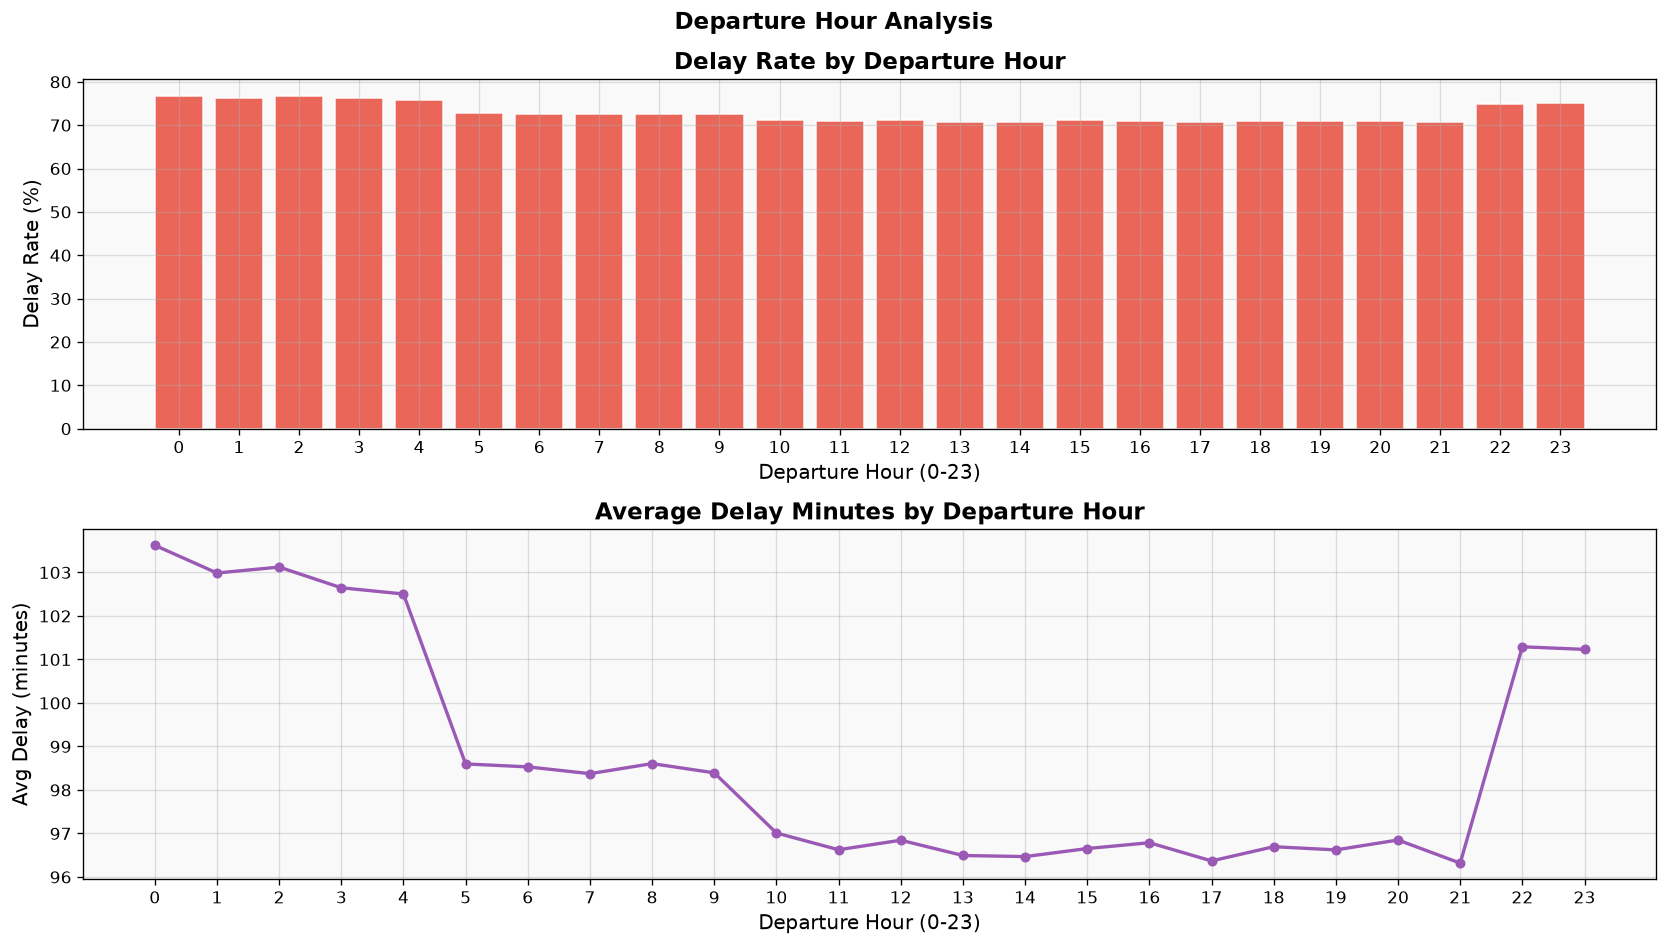

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(hourly['departure_hour'], hourly['delay_rate_pct'],
            color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title('Delay Rate by Departure Hour', fontweight='bold')
axes[0].set_xlabel('Departure Hour (0-23)')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_xticks(range(24))

axes[1].plot(hourly['departure_hour'], hourly['avg_delay'],
             marker='o', color='#9b59b6', linewidth=2, markersize=5)
axes[1].set_title('Average Delay Minutes by Departure Hour', fontweight='bold')
axes[1].set_xlabel('Departure Hour (0-23)')
axes[1].set_ylabel('Avg Delay (minutes)')
axes[1].set_xticks(range(24))

plt.suptitle('Departure Hour Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('06_hourly_delay.png')
plt.show()

In [25]:
# Peak hour, night departure, weekend comparisons
for flag in ['is_peak_hour', 'is_night_departure', 'is_weekend']:
    print(f'=== {flag} ===')
    print(flag_summary(flag).to_string(index=False))
    print()

=== is_peak_hour ===
 is_peak_hour  total  delayed  avg_delay  median_delay  delay_rate_pct
            0 797743   575540  98.005323         111.0           72.15
            1 702257   502789  97.413675         110.0           71.60

=== is_night_departure ===


 is_night_departure   total  delayed  avg_delay  median_delay  delay_rate_pct
                  0 1348985   964015  97.235403         110.0           71.46
                  1  151015   114314 102.131543         113.0           75.70

=== is_weekend ===
 is_weekend   total  delayed  avg_delay  median_delay  delay_rate_pct
          0 1070544   771806  97.932877         111.0           72.09
          1  429456   306523  97.218437         110.0           71.37



---
## Section 7 — Train Type Analysis

**Business Question:** Are certain train types associated with higher delay rates?

**Note:** Check sample sizes before drawing conclusions about small categories.

In [26]:
tt = (
    train.groupby('train_type', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
)
tt['delay_rate_pct'] = (tt['delayed'] / tt['total'] * 100).round(2)
tt = tt.sort_values('delay_rate_pct', ascending=False)

print('=== Train Type — Ranked by Delay Rate ===')
print(tt.to_string(index=False))
print()
small = tt[tt['total'] < 1000]
if not small.empty:
    print('Small sample sizes (< 1,000 journeys) — interpret cautiously:')
    print(small[['train_type', 'total']].to_string(index=False))
else:
    print('All train types have >= 1,000 journeys — sample sizes are adequate.')

=== Train Type — Ranked by Delay Rate ===
            train_type  total  delayed  avg_delay  median_delay  delay_rate_pct
       Passenger Train 119571   105276 130.533198         135.0           88.04
             DEMU/MEMU 149910   120658 120.951371         132.0           80.49
          Mail/Express 421047   334164 109.903835         119.0           79.37
     Superfast Express 179697   129053  92.323250         103.0           71.82
     Intercity Express 150155   107141 100.557404         115.0           71.35
    Garib Rath Express  44761    30878  89.077054         101.0           68.98
Sampark Kranti Express  59833    39815  86.587502         100.0           66.54
      Humsafar Express  44886    29380  85.357327          99.0           65.45
  Jan Shatabdi Express  75120    47562  83.045461          97.0           63.31
       Duronto Express  45178    28008  74.328501          84.0           61.99
      Rajdhani Express  60178    33942  61.993935          65.0           56.4

  -> Saved: ..\report\figures\eda\07_train_type_delay.png


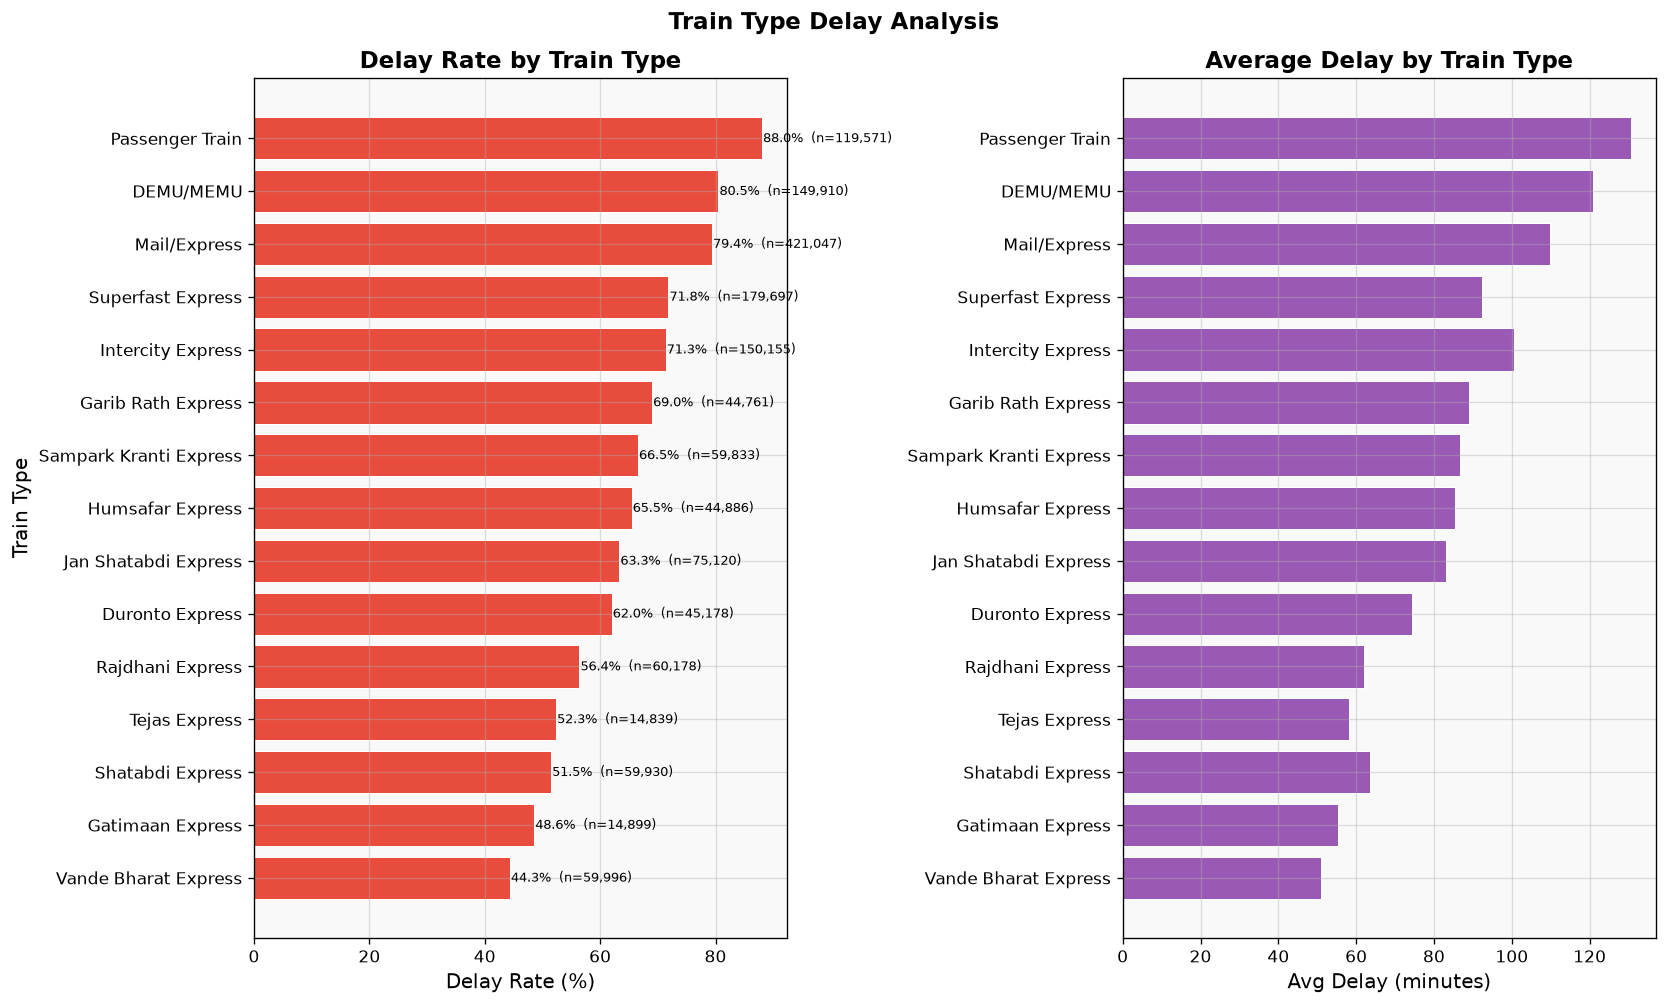

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(tt) * 0.5 + 1)))
tt_plot = tt.sort_values('delay_rate_pct')  # ascending for horizontal bar

axes[0].barh(tt_plot['train_type'], tt_plot['delay_rate_pct'],
             color='#e74c3c', edgecolor='white', linewidth=0.6)
axes[0].set_title('Delay Rate by Train Type', fontweight='bold')
axes[0].set_xlabel('Delay Rate (%)')
axes[0].set_ylabel('Train Type')
for i, (v, t) in enumerate(zip(tt_plot['delay_rate_pct'], tt_plot['total'])):
    axes[0].text(v + 0.2, i, f'{v:.1f}%  (n={t:,})', va='center', fontsize=8)

axes[1].barh(tt_plot['train_type'], tt_plot['avg_delay'],
             color='#9b59b6', edgecolor='white', linewidth=0.6)
axes[1].set_title('Average Delay by Train Type', fontweight='bold')
axes[1].set_xlabel('Avg Delay (minutes)')
axes[1].set_ylabel('')

plt.suptitle('Train Type Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('07_train_type_delay.png')
plt.show()

---
## Section 8 — Zone / Railway Zone Analysis

**Business Question:** Which railway zones show the highest delay rates and severity?

In [28]:
zone_grp = (
    train.groupby('zone_abbr', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
        avg_congestion=('zone_congestion_index', 'mean'),
        avg_fog_idx=('zone_fog_index', 'mean'),
    )
    .reset_index()
)
zone_grp['delay_rate_pct'] = (zone_grp['delayed'] / zone_grp['total'] * 100).round(2)
zone_grp = zone_grp.sort_values('delay_rate_pct', ascending=False)

print('=== Zone Delay Summary (ranked by delay rate) ===')
print(zone_grp.to_string(index=False))

=== Zone Delay Summary (ranked by delay rate) ===
zone_abbr  total  delayed  avg_delay  median_delay  avg_congestion  avg_fog_idx  delay_rate_pct
       ER  93698    83695 120.518944         122.0            0.95         0.32           89.32
       NR  93185    81590 118.031840         121.0            0.92         0.88           87.56
      NCR  93754    79642 114.602289         119.0            0.90         0.82           84.95
      ECR  93888    79590 114.029961         119.0            0.88         0.55           84.77
      NER  94535    75474 107.411932         116.0            0.82         0.78           79.84
       CR  93702    73563 106.502081         116.0            0.85         0.05           78.51
      WCR  93621    71916 103.542838         114.0            0.80         0.42           76.82
       WR  93318    70076 102.345303         113.0            0.83         0.05           75.09
      NWR  93621    67985  98.058448         110.0            0.75         0.58       

  -> Saved: ..\report\figures\eda\08_zone_delay.png


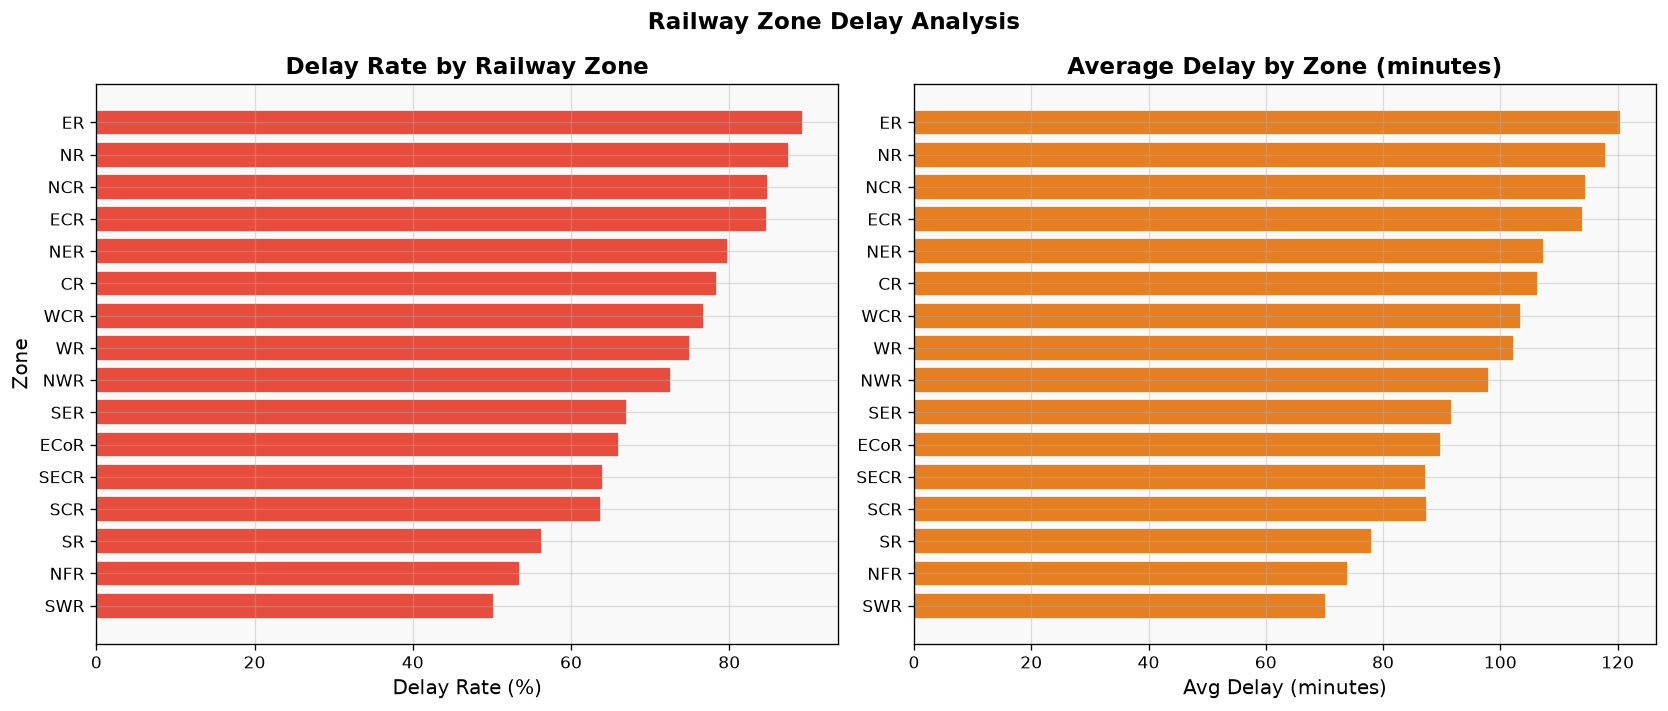

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
zp = zone_grp.sort_values('delay_rate_pct')

axes[0].barh(zp['zone_abbr'], zp['delay_rate_pct'], color='#e74c3c', edgecolor='white')
axes[0].set_title('Delay Rate by Railway Zone', fontweight='bold')
axes[0].set_xlabel('Delay Rate (%)')
axes[0].set_ylabel('Zone')

axes[1].barh(zp['zone_abbr'], zp['avg_delay'], color='#e67e22', edgecolor='white')
axes[1].set_title('Average Delay by Zone (minutes)', fontweight='bold')
axes[1].set_xlabel('Avg Delay (minutes)')

plt.suptitle('Railway Zone Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('08_zone_delay.png')
plt.show()

---
## Section 9 — Station Category Analysis

**Business Question:** Do source or destination station categories show different delay patterns?

In [30]:
def station_cat_summary(col):
    grp = (
        train.groupby(col, observed=True)
        .agg(
            total=('journey_id', 'count'),
            delayed=('is_delayed', 'sum'),
            avg_delay=('delay_minutes', 'mean'),
        )
        .reset_index()
    )
    grp['delay_rate_pct'] = (grp['delayed'] / grp['total'] * 100).round(2)
    return grp.sort_values('delay_rate_pct', ascending=False)

src = station_cat_summary('source_station_category')
dst = station_cat_summary('destination_station_category')

print('=== Source Station Category ===')
print(src.to_string(index=False))
print()
print('=== Destination Station Category ===')
print(dst.to_string(index=False))

=== Source Station Category ===
source_station_category  total  delayed  avg_delay  delay_rate_pct
                      A 180103   129638  97.901645           71.98
                     A1 120329    86616  97.788954           71.98
                      D 299817   215588  97.801976           71.91
                      C 329188   236613  97.639091           71.88
                      E 300937   216249  97.674882           71.86
                      B 269626   193625  97.672220           71.81

=== Destination Station Category ===
destination_station_category  total  delayed  avg_delay  delay_rate_pct
                           C 330330   237675  97.839246           71.95
                           A 180326   129731  97.718172           71.94
                           D 299915   215749  97.892483           71.94
                           E 298910   214788  97.720073           71.86
                          A1 120587    86637  97.702762           71.85
                           B 

  -> Saved: ..\report\figures\eda\09_station_category_delay.png


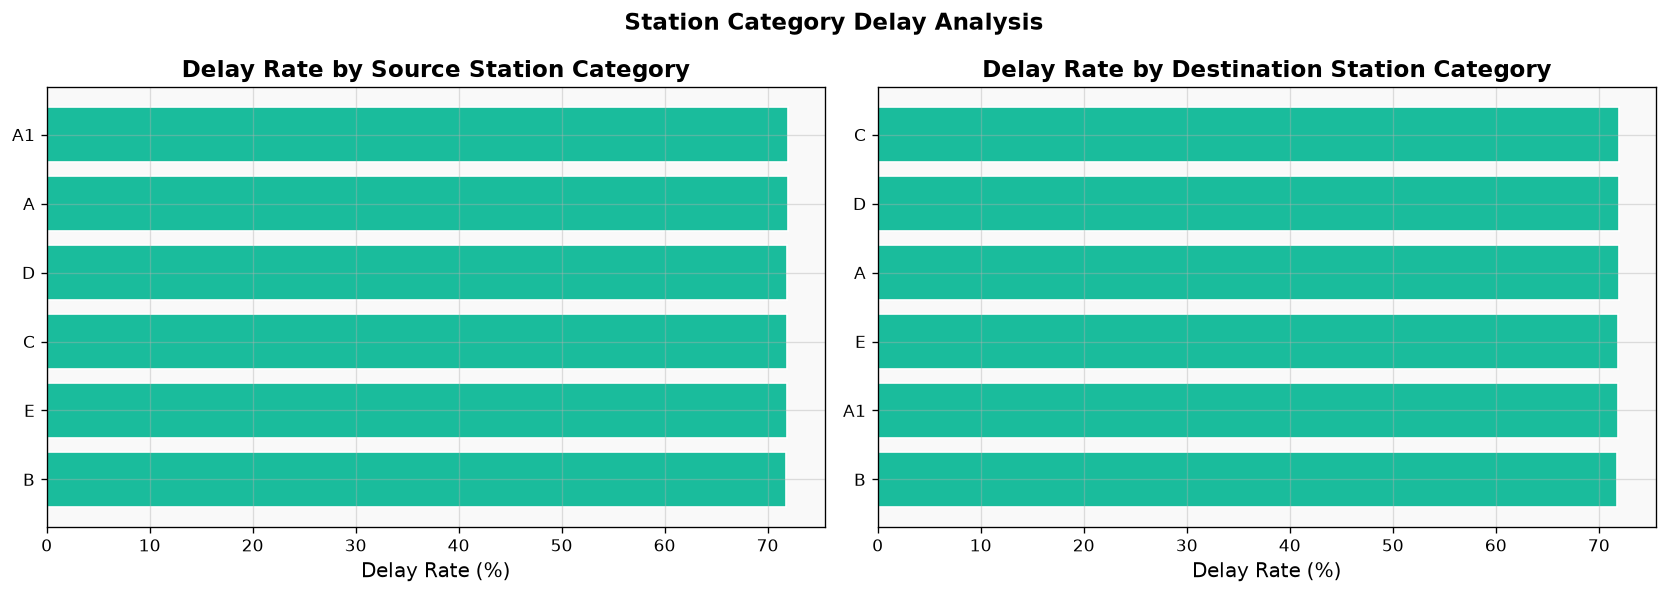

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, label in [
    (axes[0], src.sort_values('delay_rate_pct'), 'Source'),
    (axes[1], dst.sort_values('delay_rate_pct'), 'Destination'),
]:
    ax.barh(df.iloc[:, 0], df['delay_rate_pct'], color='#1abc9c', edgecolor='white')
    ax.set_title(f'Delay Rate by {label} Station Category', fontweight='bold')
    ax.set_xlabel('Delay Rate (%)')

plt.suptitle('Station Category Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('09_station_category_delay.png')
plt.show()

---
## Section 10 — Distance and Travel Duration

**Business Question:** Are longer routes or more stops associated with higher delays?

**Scatter plots:** Aggregated/sampled to avoid overplotting 1.5M points.

In [32]:
route_vars = ['distance_km', 'num_scheduled_stops', 'scheduled_travel_hours', 'delay_minutes']
corr_route = train[route_vars].corr().round(3)
print('=== Correlation: Route Variables vs delay_minutes ===')
print(corr_route)

=== Correlation: Route Variables vs delay_minutes ===
                        distance_km  num_scheduled_stops  \
distance_km                   1.000                0.000   
num_scheduled_stops           0.000                1.000   
scheduled_travel_hours        0.952                0.000   
delay_minutes                -0.131                0.008   

                        scheduled_travel_hours  delay_minutes  
distance_km                              0.952         -0.131  
num_scheduled_stops                      0.000          0.008  
scheduled_travel_hours                   1.000         -0.052  
delay_minutes                           -0.052          1.000  


In [33]:
train['dist_bin'] = pd.cut(
    train['distance_km'],
    bins=[0, 200, 500, 1000, 1500, 2000, 10000],
    labels=['<200km', '200-500km', '500-1000km', '1000-1500km', '1500-2000km', '>2000km'],
)
dist_grp = (
    train.groupby('dist_bin', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
)
dist_grp['delay_rate_pct'] = (dist_grp['delayed'] / dist_grp['total'] * 100).round(2)
print('=== Distance Bins vs Delay ===')
print(dist_grp.to_string(index=False))
train.drop(columns=['dist_bin'], inplace=True)

=== Distance Bins vs Delay ===
   dist_bin  total  delayed  avg_delay  median_delay  delay_rate_pct
     <200km 158480   128669 121.482660         132.0           81.19
  200-500km 509418   362147  98.767260         113.0           71.09
 500-1000km 632846   453980  95.630381         108.0           71.74
1000-1500km 156317   105750  85.005259          96.0           67.65
1500-2000km  34775    22423  75.470625          84.0           64.48
    >2000km   8164     5360  72.824718          79.0           65.65


  -> Saved: ..\report\figures\eda\10_distance_stops_delay.png


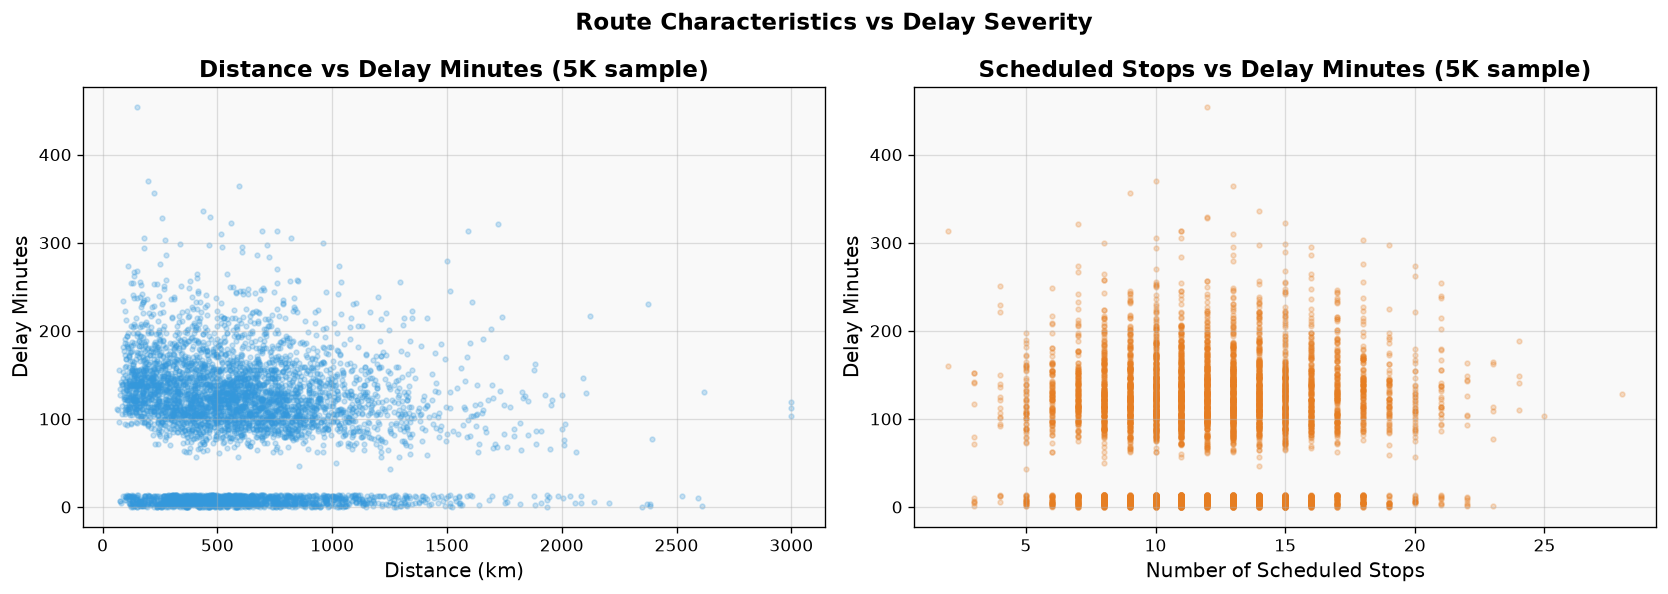

In [34]:
# Use 5K sample for scatter (avoids plotting 1.5M overlapping points)
sample = train.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['distance_km'], sample['delay_minutes'],
                alpha=0.25, s=8, color='#3498db')
axes[0].set_title('Distance vs Delay Minutes (5K sample)', fontweight='bold')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Delay Minutes')

axes[1].scatter(sample['num_scheduled_stops'], sample['delay_minutes'],
                alpha=0.25, s=8, color='#e67e22')
axes[1].set_title('Scheduled Stops vs Delay Minutes (5K sample)', fontweight='bold')
axes[1].set_xlabel('Number of Scheduled Stops')
axes[1].set_ylabel('Delay Minutes')

plt.suptitle('Route Characteristics vs Delay Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('10_distance_stops_delay.png')
plt.show()

---
## Section 11 — Infrastructure / Route Characteristics

**Business Question:** Are track doubling, electrification, HDN routes, or PSR counts associated with delays?

In [35]:
infra_flags = ['track_doubled', 'is_hdn_route', 'is_electrified', 'is_circular_route']
for flag in infra_flags:
    print(f'=== {flag} ===')
    print(flag_summary(flag).to_string(index=False))
    print()

# Traction type (categorical)
traction = (
    train.groupby('traction_type', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
    )
    .reset_index()
)
traction['delay_rate_pct'] = (traction['delayed'] / traction['total'] * 100).round(2)
print('=== traction_type ===')
print(traction.sort_values('delay_rate_pct', ascending=False).to_string(index=False))

=== track_doubled ===
 track_doubled  total  delayed  avg_delay  median_delay  delay_rate_pct
             0 525086   432906 109.303346         115.0           82.44
             1 974914   645423  91.494058         107.0           66.20

=== is_hdn_route ===


 is_hdn_route   total  delayed  avg_delay  median_delay  delay_rate_pct
            0 1050718   743224  96.476698         110.0           70.73
            1  449282   335105 100.655473         112.0           74.59

=== is_electrified ===
 is_electrified   total  delayed  avg_delay  median_delay  delay_rate_pct
              0  225611   176262 104.528197         114.0           78.13
              1 1274389   902067  96.524518         110.0           70.78

=== is_circular_route ===


 is_circular_route   total  delayed  avg_delay  median_delay  delay_rate_pct
                 0 1379833   991742  97.706637         110.0           71.87
                 1  120167    86587  97.977423         111.0           72.06

=== traction_type ===
     traction_type   total  delayed  avg_delay  delay_rate_pct
            Diesel  225611   176262 104.528197           78.13
              Dual   45125    32088  96.918715           71.11
Electric (25kV AC) 1229264   869979  96.510047           70.77


In [36]:
psr_grp = (
    train.groupby('psr_count', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
    )
    .reset_index()
    .sort_values('psr_count')
)
psr_grp['delay_rate_pct'] = (psr_grp['delayed'] / psr_grp['total'] * 100).round(2)
print('=== psr_count (Permanent Speed Restriction count) vs Delay ===')
print(psr_grp.to_string(index=False))

=== psr_count (Permanent Speed Restriction count) vs Delay ===
 psr_count  total  delayed  avg_delay  delay_rate_pct
         0  74600    52504  96.207105           70.38
         1 223375   157532  96.145531           70.52
         2 336735   240411  97.196252           71.39
         3 336138   241258  97.545035           71.77
         4 252086   183072  98.678971           72.62
         5 151461   110585  98.880319           73.01
         6  75541    55745 100.024450           73.79
         7  32032    23708  99.746878           74.01
         8  12148     9052  99.886236           74.51
         9   4182     3160 102.468914           75.56
        10   1256      959 103.637739           76.35
        11    326      243  98.046012           74.54
        12     94       77 111.319149           81.91
        13     22       20 133.727273           90.91
        14      2        1  54.500000           50.00
        15      2        2 118.000000          100.00


  -> Saved: ..\report\figures\eda\11_infrastructure_delay.png


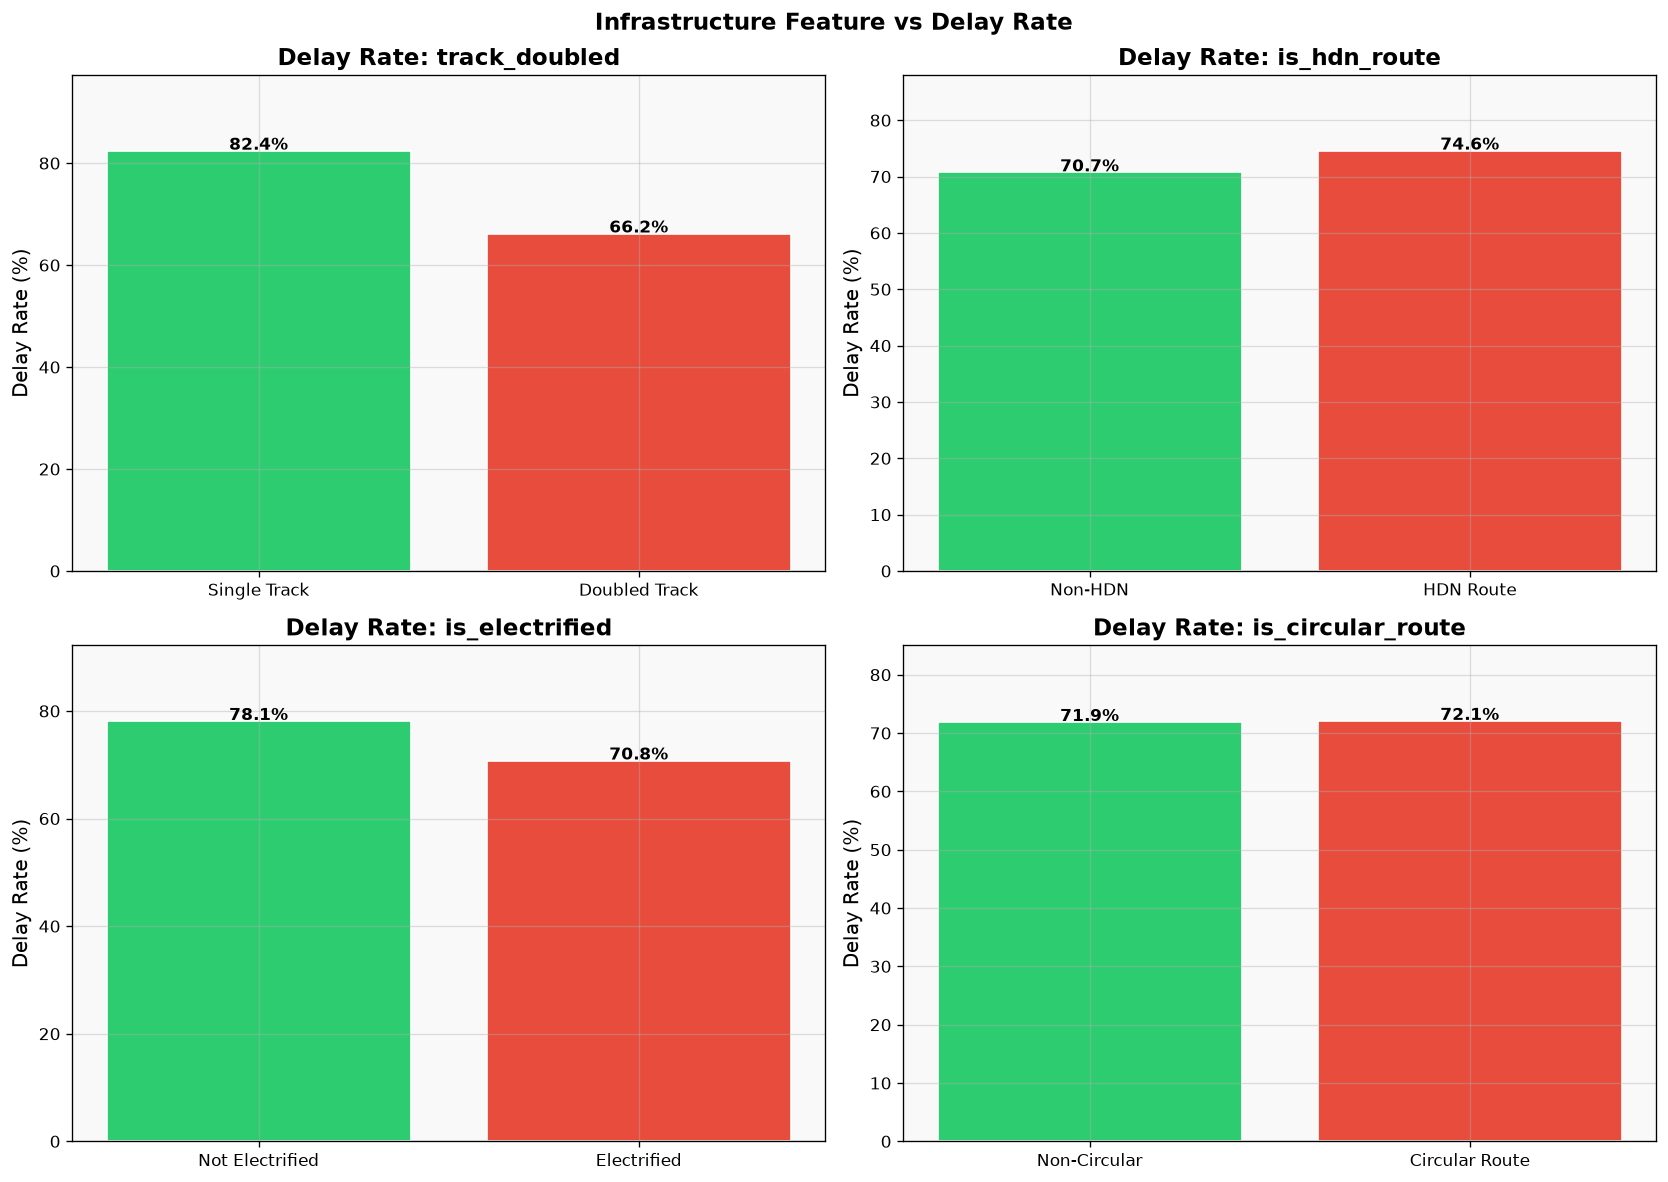

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

flag_labels = {
    'track_doubled':    ['Single Track', 'Doubled Track'],
    'is_hdn_route':     ['Non-HDN', 'HDN Route'],
    'is_electrified':   ['Not Electrified', 'Electrified'],
    'is_circular_route':['Non-Circular', 'Circular Route'],
}
for ax, flag in zip(axes, infra_flags):
    grp = flag_summary(flag)
    bar_labels = flag_labels.get(flag, [str(v) for v in grp[flag]])
    colors_f = ['#2ecc71', '#e74c3c'] if len(grp) == 2 else sns.color_palette('tab10', len(grp))
    bars = ax.bar(
        bar_labels[:len(grp)], grp['delay_rate_pct'],
        color=colors_f[:len(grp)], edgecolor='white',
    )
    for bar, v in zip(bars, grp['delay_rate_pct']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Delay Rate: {flag}', fontweight='bold')
    ax.set_ylabel('Delay Rate (%)')
    ax.set_ylim(0, max(grp['delay_rate_pct']) * 1.18)

plt.suptitle('Infrastructure Feature vs Delay Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('11_infrastructure_delay.png')
plt.show()

---
## Section 12 — Weather / Seasonal Risk

**Business Question:** Are delays associated with fog risk, monsoon conditions, or seasonal severity?

**Caution:** Observed associations, not proven causal links.

In [38]:
print('=== is_fog_risk ===')
print(flag_summary('is_fog_risk').to_string(index=False))
print()
print('=== is_monsoon_season ===')
print(flag_summary('is_monsoon_season').to_string(index=False))
print()
# Fog risk score bins
train['fog_bin'] = pd.cut(train['fog_risk_score'], bins=5, precision=2)
fog_grp = (
    train.groupby('fog_bin', observed=True)
    .agg(total=('journey_id','count'), delayed=('is_delayed','sum'), avg_delay=('delay_minutes','mean'))
    .reset_index()
)
fog_grp['delay_rate_pct'] = (fog_grp['delayed'] / fog_grp['total'] * 100).round(2)
print('=== fog_risk_score bins ===')
print(fog_grp.to_string(index=False))
train.drop(columns=['fog_bin'], inplace=True)
print()
print('=== Zone Fog Index vs Zone Delay Rate ===')
print(
    zone_grp[['zone_abbr','avg_fog_idx','delay_rate_pct']]
    .sort_values('avg_fog_idx', ascending=False)
    .to_string(index=False)
)

=== is_fog_risk ===
 is_fog_risk   total  delayed  avg_delay  median_delay  delay_rate_pct
           0 1444865  1025541  96.549012         110.0           70.98
           1   55135    52788 128.633481         126.0           95.74

=== is_monsoon_season ===


 is_monsoon_season  total  delayed  avg_delay  median_delay  delay_rate_pct
                 0 999202   613477  83.220149          98.0           61.40
                 1 500798   464852 126.675338         126.0           92.82

=== fog_risk_score bins ===
         fog_bin   total  delayed  avg_delay  delay_rate_pct
(-0.00088, 0.18] 1413278  1002314  96.478136           70.92
    (0.18, 0.35]   39475    30844 106.127802           78.14
    (0.35, 0.53]    7921     7242 122.920843           91.43
     (0.53, 0.7]   15754    14823 125.363908           94.09
     (0.7, 0.88]   23572    23106 131.683099           98.02

=== Zone Fog Index vs Zone Delay Rate ===
zone_abbr  avg_fog_idx  delay_rate_pct
       NR         0.88           87.56
      NCR         0.82           84.95
      NER         0.78           79.84
      NWR         0.58           72.62
      ECR         0.55           84.77
      WCR         0.42           76.82
       ER         0.32           89.32
     SECR         0.28

  -> Saved: ..\report\figures\eda\12_weather_risk_delay.png


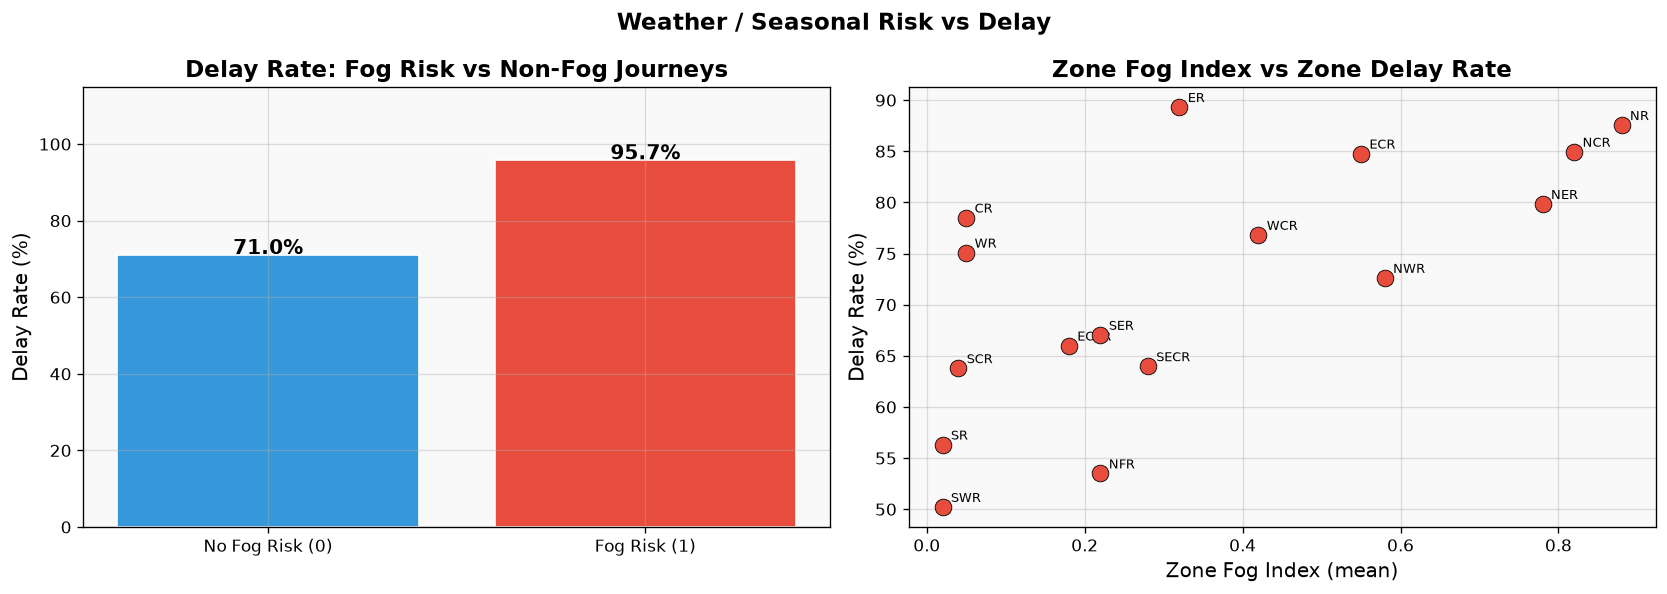

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fog_flag = flag_summary('is_fog_risk')
axes[0].bar(['No Fog Risk (0)', 'Fog Risk (1)'], fog_flag['delay_rate_pct'],
            color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Delay Rate: Fog Risk vs Non-Fog Journeys', fontweight='bold')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_ylim(0, max(fog_flag['delay_rate_pct']) * 1.2)
for bar, v in zip(axes[0].patches, fog_flag['delay_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

axes[1].scatter(zone_grp['avg_fog_idx'], zone_grp['delay_rate_pct'],
                s=100, color='#e74c3c', edgecolors='black', linewidth=0.5, zorder=5)
for _, row in zone_grp.iterrows():
    axes[1].annotate(
        row['zone_abbr'],
        (row['avg_fog_idx'], row['delay_rate_pct']),
        textcoords='offset points', xytext=(5, 3), fontsize=8,
    )
axes[1].set_title('Zone Fog Index vs Zone Delay Rate', fontweight='bold')
axes[1].set_xlabel('Zone Fog Index (mean)')
axes[1].set_ylabel('Delay Rate (%)')

plt.suptitle('Weather / Seasonal Risk vs Delay', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('12_weather_risk_delay.png')
plt.show()

---
## Section 13 — Train Condition / Operational Factors

**Business Question:** Are fleet age, maintenance quality, rake status, or load associated with delays?

**Focus:** `late_incoming_rake` — operationally important indicator.

In [40]:
print('=== late_incoming_rake ===')
print(flag_summary('late_incoming_rake').to_string(index=False))
print()
print(
    'OPERATIONAL CONTEXT: late_incoming_rake=1 means the rake arrived already delayed.\n'
    'Operationally, a late arriving rake may cause the outgoing journey to start late.\n'
    'We observe the ASSOCIATION here — causality is not confirmed from EDA alone.'
)
print()
for flag in ['has_lhb_coaches', 'is_rake_shared', 'is_special_train']:
    print(f'=== {flag} ===')
    print(flag_summary(flag).to_string(index=False))
    print()

=== late_incoming_rake ===
 late_incoming_rake  total  delayed  avg_delay  median_delay  delay_rate_pct
                  0 976208   622376  80.221355          95.0           63.75
                  1 523792   455953 130.356642         136.0           87.05

OPERATIONAL CONTEXT: late_incoming_rake=1 means the rake arrived already delayed.
Operationally, a late arriving rake may cause the outgoing journey to start late.
We observe the ASSOCIATION here — causality is not confirmed from EDA alone.

=== has_lhb_coaches ===


 has_lhb_coaches  total  delayed  avg_delay  median_delay  delay_rate_pct
               0 600589   448981 100.935099         112.0           74.76
               1 899411   629348  95.586984         109.0           69.97

=== is_rake_shared ===
 is_rake_shared  total  delayed  avg_delay  median_delay  delay_rate_pct
              0 825372   575696  95.344973         109.0           69.75
              1 674628   502633 100.644242         112.0           74.51

=== is_special_train ===


 is_special_train   total  delayed  avg_delay  median_delay  delay_rate_pct
                0 1350055   970166  97.700510         110.0           71.86
                1  149945   108163  97.978812         111.0           72.14



In [41]:
# Loco age groups
train['loco_age_group'] = pd.cut(
    train['loco_age_years'],
    bins=[0, 5, 10, 15, 20, 100],
    labels=['0-5yr', '5-10yr', '10-15yr', '15-20yr', '>20yr'],
)
loco_grp = (
    train.groupby('loco_age_group', observed=True)
    .agg(total=('journey_id','count'), delayed=('is_delayed','sum'), avg_delay=('delay_minutes','mean'))
    .reset_index()
)
loco_grp['delay_rate_pct'] = (loco_grp['delayed'] / loco_grp['total'] * 100).round(2)
print('=== Loco Age Groups ===')
print(loco_grp.to_string(index=False))
train.drop(columns=['loco_age_group'], inplace=True)
print()

# Coach age groups
train['coach_age_group'] = pd.cut(
    train['coach_age_years'],
    bins=[0, 5, 10, 15, 20, 100],
    labels=['0-5yr', '5-10yr', '10-15yr', '15-20yr', '>20yr'],
)
coach_grp = (
    train.groupby('coach_age_group', observed=True)
    .agg(total=('journey_id','count'), delayed=('is_delayed','sum'), avg_delay=('delay_minutes','mean'))
    .reset_index()
)
coach_grp['delay_rate_pct'] = (coach_grp['delayed'] / coach_grp['total'] * 100).round(2)
print('=== Coach Age Groups ===')
print(coach_grp.to_string(index=False))
train.drop(columns=['coach_age_group'], inplace=True)

=== Loco Age Groups ===
loco_age_group  total  delayed  avg_delay  delay_rate_pct
         0-5yr 198767   132861  92.079259           66.84
        5-10yr 338369   232786  94.311757           68.80
       10-15yr 304433   215284  96.423640           70.72
       15-20yr 229404   166759  98.716461           72.69
         >20yr 429003   330624 103.438722           77.07



=== Coach Age Groups ===
coach_age_group  total  delayed  avg_delay  delay_rate_pct
          0-5yr  39177    26772  94.030400           68.34
         5-10yr 160169   110469  94.453159           68.97
        10-15yr 237752   166243  95.695889           69.92
        15-20yr 249920   177047  96.575692           70.84
          >20yr 812982   597798  99.500496           73.53


In [42]:
# Maintenance score groups
train['maint_group'] = pd.cut(train['maintenance_score'], bins=5, precision=1)
maint_grp = (
    train.groupby('maint_group', observed=True)
    .agg(total=('journey_id','count'), delayed=('is_delayed','sum'), avg_delay=('delay_minutes','mean'))
    .reset_index()
)
maint_grp['delay_rate_pct'] = (maint_grp['delayed'] / maint_grp['total'] * 100).round(2)
print('=== Maintenance Score Groups ===')
print(maint_grp.to_string(index=False))
train.drop(columns=['maint_group'], inplace=True)
print()

# Seat utilisation groups
train['util_group'] = pd.cut(
    train['seat_utilisation_pct'],
    bins=[0, 60, 80, 100, 120, 200],
    labels=['<60%', '60-80%', '80-100%', '100-120%', '>120%'],
)
util_grp = (
    train.groupby('util_group', observed=True)
    .agg(total=('journey_id','count'), delayed=('is_delayed','sum'), avg_delay=('delay_minutes','mean'))
    .reset_index()
)
util_grp['delay_rate_pct'] = (util_grp['delayed'] / util_grp['total'] * 100).round(2)
print('=== Seat Utilisation Groups ===')
print(util_grp.to_string(index=False))
train.drop(columns=['util_group'], inplace=True)

=== Maintenance Score Groups ===
maint_group  total  delayed  avg_delay  delay_rate_pct
 (1.0, 2.8]  32096    23295  98.497227           72.58
 (2.8, 4.6] 196353   142533  98.452257           72.59
 (4.6, 6.4] 505703   364219  97.786098           72.02
 (6.4, 8.2] 517933   371412  97.610349           71.71
(8.2, 10.0] 247915   176870  97.184067           71.34



=== Seat Utilisation Groups ===
util_group  total  delayed  avg_delay  delay_rate_pct
      <60% 351316   252496  97.782899           71.87
    60-80% 633630   455346  97.695466           71.86
   80-100% 515054   370487  97.731539           71.93


  -> Saved: ..\report\figures\eda\13_operational_factors_delay.png


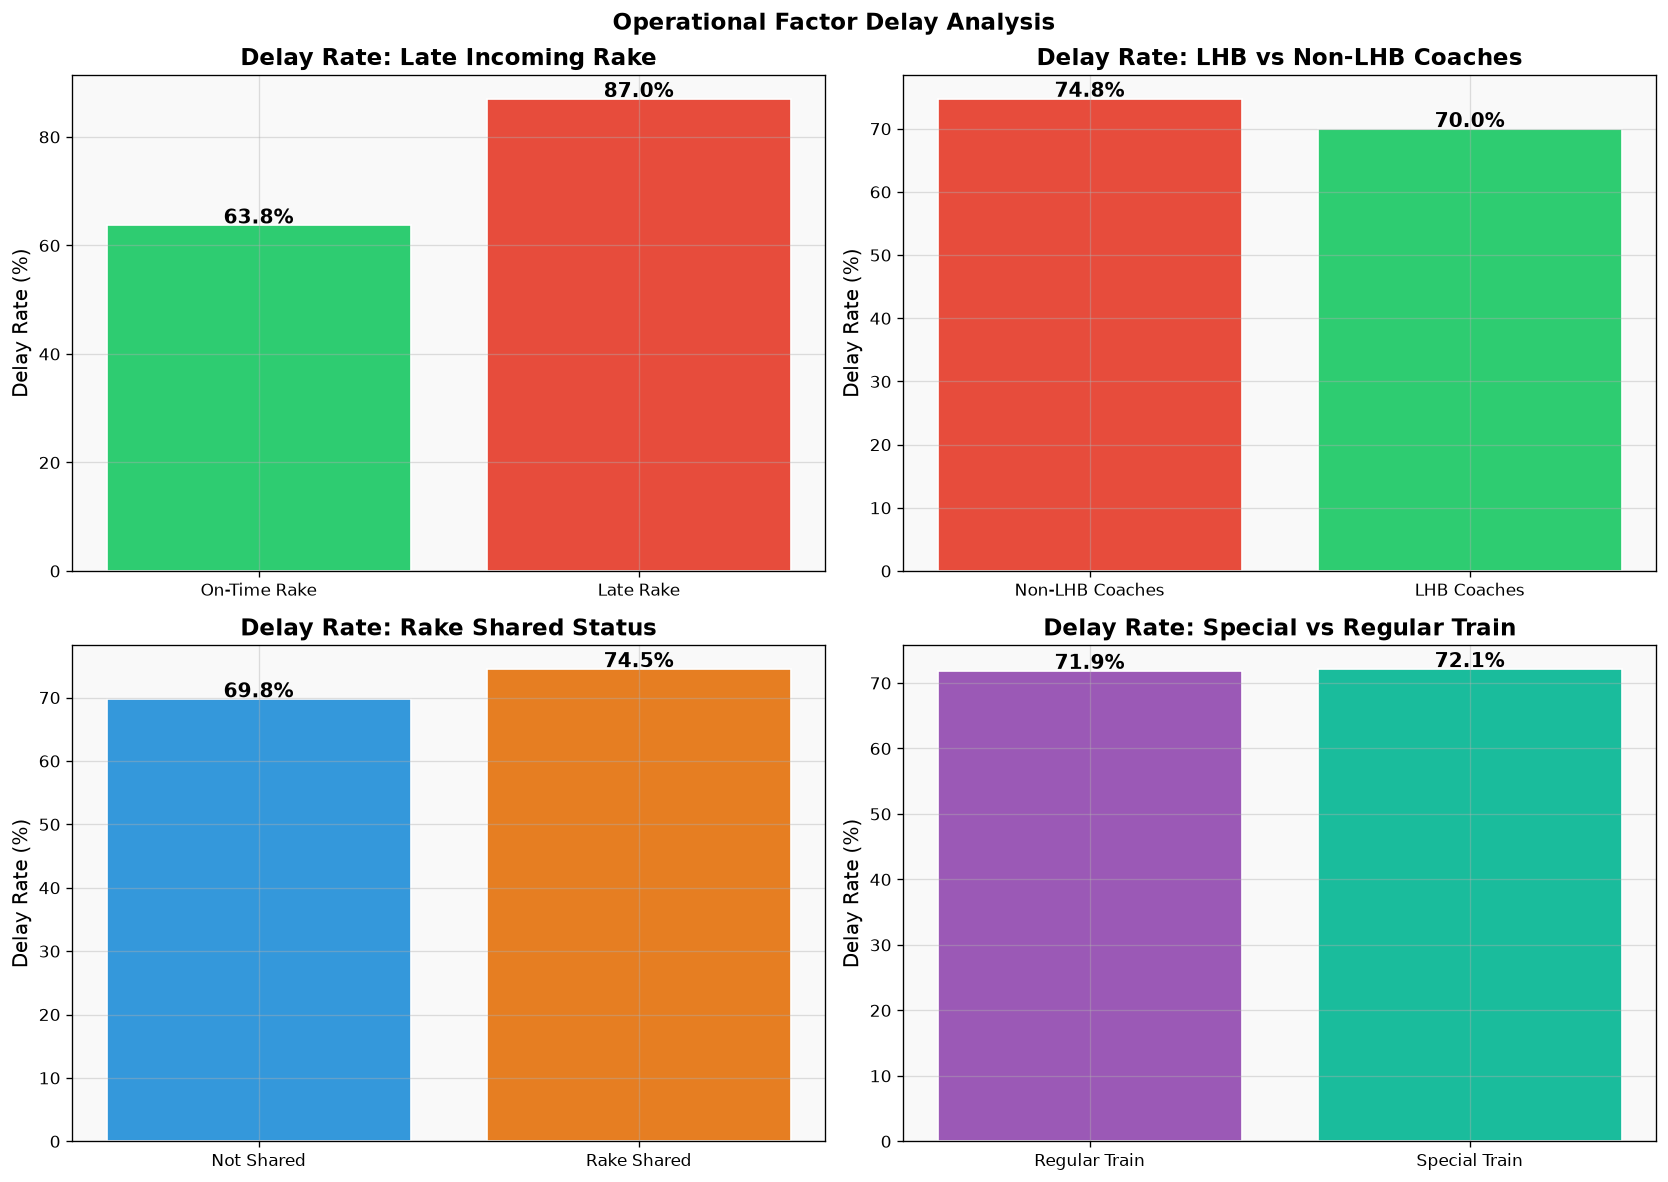

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

def ops_bar(ax, flag, labels, colors, title):
    grp = flag_summary(flag)
    bars = ax.bar(labels[:len(grp)], grp['delay_rate_pct'],
                  color=colors[:len(grp)], edgecolor='white')
    for bar, v in zip(bars, grp['delay_rate_pct']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Delay Rate (%)')

ops_bar(axes[0], 'late_incoming_rake',
        ['On-Time Rake', 'Late Rake'], ['#2ecc71', '#e74c3c'],
        'Delay Rate: Late Incoming Rake')
ops_bar(axes[1], 'has_lhb_coaches',
        ['Non-LHB Coaches', 'LHB Coaches'], ['#e74c3c', '#2ecc71'],
        'Delay Rate: LHB vs Non-LHB Coaches')
ops_bar(axes[2], 'is_rake_shared',
        ['Not Shared', 'Rake Shared'], ['#3498db', '#e67e22'],
        'Delay Rate: Rake Shared Status')
ops_bar(axes[3], 'is_special_train',
        ['Regular Train', 'Special Train'], ['#9b59b6', '#1abc9c'],
        'Delay Rate: Special vs Regular Train')

plt.suptitle('Operational Factor Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('13_operational_factors_delay.png')
plt.show()

---
## Section 14 — Route Historical Performance

**Business Question:** Do routes with historically low on-time performance also show higher current delay rates?

In [44]:
train['hist_ontime_bin'] = pd.cut(
    train['route_historical_ontime_pct'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'],
)
hist_grp = (
    train.groupby('hist_ontime_bin', observed=True)
    .agg(
        total=('journey_id', 'count'),
        delayed=('is_delayed', 'sum'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
)
hist_grp['delay_rate_pct'] = (hist_grp['delayed'] / hist_grp['total'] * 100).round(2)
print('=== Historical On-Time % vs Current Delay Rate ===')
print(hist_grp.to_string(index=False))
train.drop(columns=['hist_ontime_bin'], inplace=True)

=== Historical On-Time % vs Current Delay Rate ===
hist_ontime_bin  total  delayed  avg_delay  median_delay  delay_rate_pct
         20-40%  50383    49336 138.065518         133.0           97.92
         40-60% 560206   494595 119.808005         123.0           88.29
         60-80% 757539   490903  87.505124         102.0           64.80
        80-100% 131872    43495  47.247581          11.0           32.98


  -> Saved: ..\report\figures\eda\14_historical_performance.png


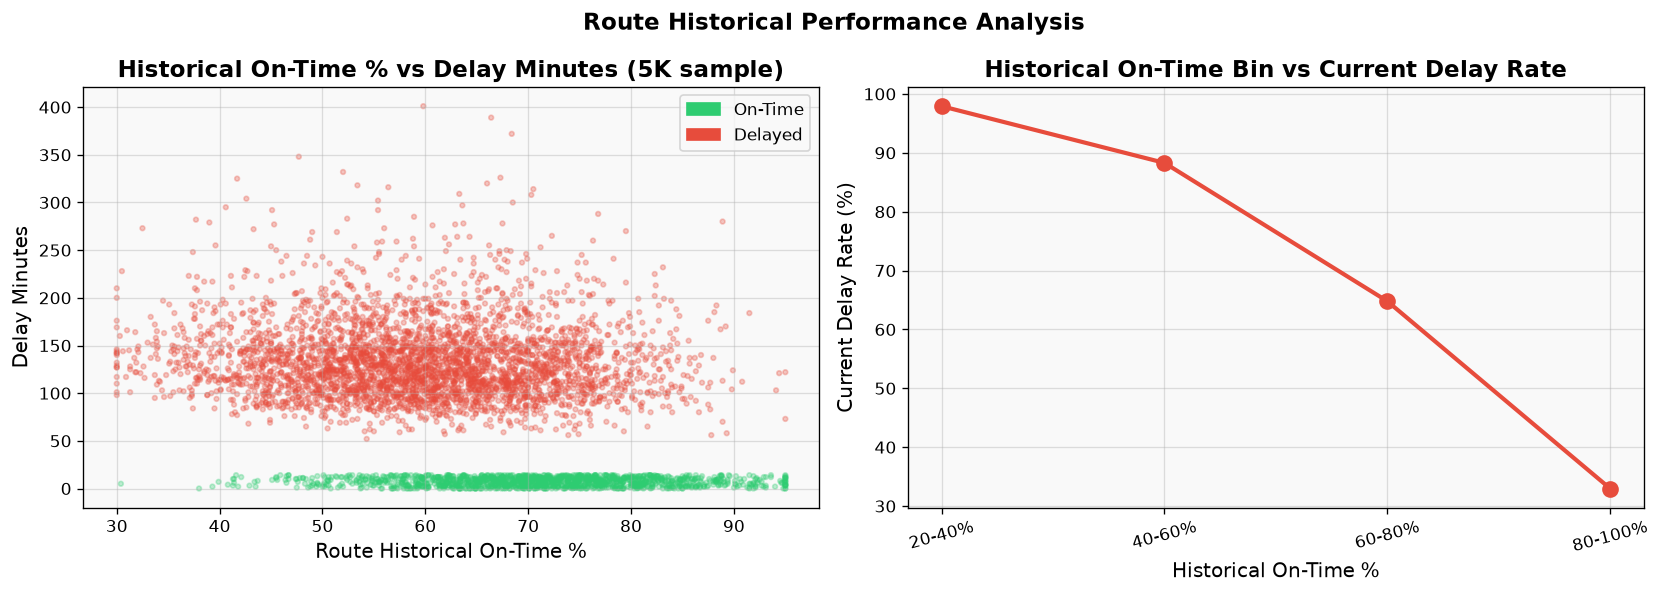

In [45]:
sample14 = train.sample(n=5000, random_state=7)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors14 = ['#2ecc71' if v == 0 else '#e74c3c' for v in sample14['is_delayed']]
axes[0].scatter(sample14['route_historical_ontime_pct'], sample14['delay_minutes'],
                c=colors14, alpha=0.3, s=8)
axes[0].set_title('Historical On-Time % vs Delay Minutes (5K sample)', fontweight='bold')
axes[0].set_xlabel('Route Historical On-Time %')
axes[0].set_ylabel('Delay Minutes')
axes[0].legend(handles=[
    Patch(color='#2ecc71', label='On-Time'),
    Patch(color='#e74c3c', label='Delayed'),
])

axes[1].plot(hist_grp['hist_ontime_bin'], hist_grp['delay_rate_pct'],
             marker='o', color='#e74c3c', linewidth=2.5, markersize=9)
axes[1].set_title('Historical On-Time Bin vs Current Delay Rate', fontweight='bold')
axes[1].set_xlabel('Historical On-Time %')
axes[1].set_ylabel('Current Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Route Historical Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('14_historical_performance.png')
plt.show()

---
## Section 15 — Primary Delay Cause

**Business Question:** What are the most frequent delay causes, and which are most severe?

In [46]:
cause_grp = (
    train.groupby('primary_delay_cause', observed=True)
    .agg(
        journey_count=('journey_id', 'count'),
        avg_delay=('delay_minutes', 'mean'),
        median_delay=('delay_minutes', 'median'),
    )
    .reset_index()
)
cause_grp['pct_of_journeys'] = (cause_grp['journey_count'] / len(train) * 100).round(2)
cause_grp = cause_grp.sort_values('journey_count', ascending=False)

print('=== Primary Delay Cause Summary ===')
print(cause_grp.to_string(index=False))

=== Primary Delay Cause Summary ===
    primary_delay_cause  journey_count  avg_delay  median_delay  pct_of_journeys
                On Time         421671   6.999938           7.0            28.11
       Track Congestion         241693 134.699102         128.0            16.11
Flooding / Waterlogging         208900 135.812968         129.0            13.93
     Late Incoming Rake         162183 144.950137         137.0            10.81
Track Maintenance / PSR         139761 136.013995         129.0             9.32
     Station Congestion          71834 133.788373         127.0             4.79
         Signal Failure          40735 122.406235         114.0             2.72
   Level Crossing Delay          31456 118.549911         110.0             2.10
    Passenger Emergency          31352 118.759122         110.0             2.09
       Freight Priority          31240 118.873592         110.0             2.08
       Unscheduled Halt          31208 119.095264         110.0          

  -> Saved: ..\report\figures\eda\15_primary_delay_cause.png


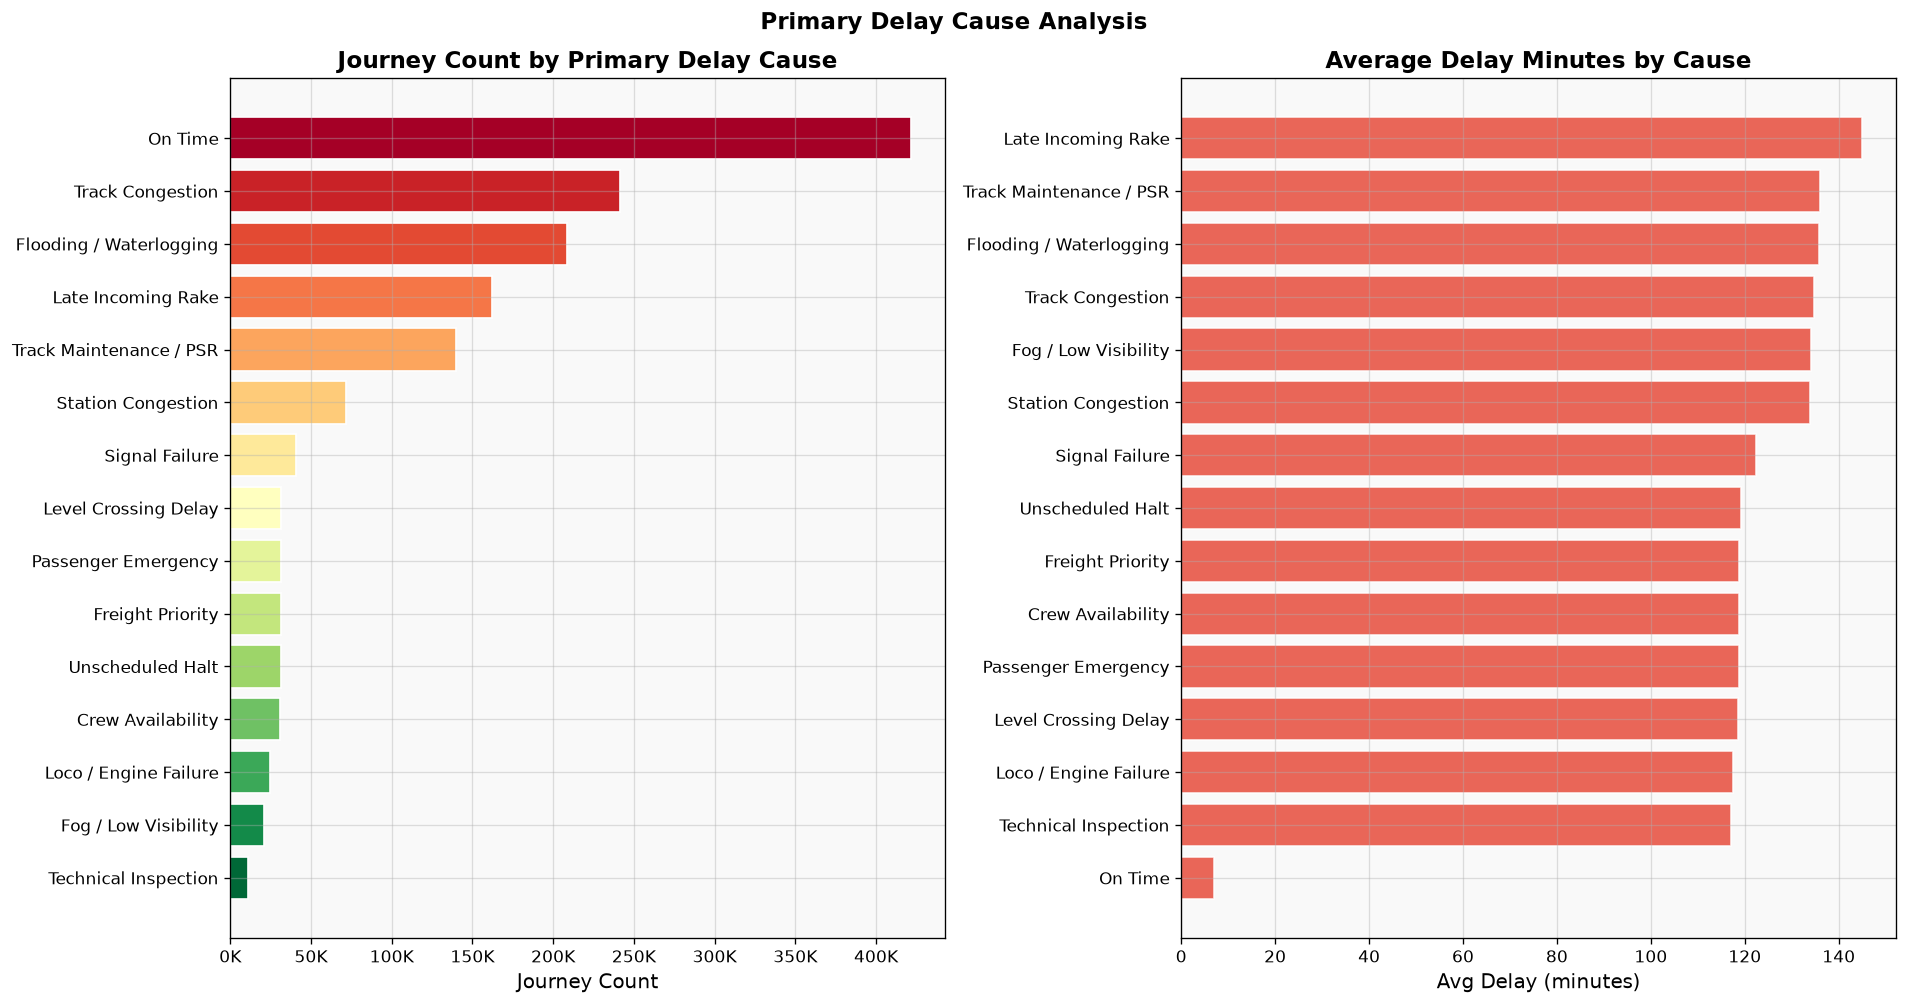

In [47]:
cause_plot = cause_grp.sort_values('journey_count')
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(cause_plot) * 0.5 + 1)))

cmap = plt.get_cmap('RdYlGn_r', len(cause_plot))
colors_c = [cmap(i) for i in range(len(cause_plot))]
axes[0].barh(cause_plot['primary_delay_cause'], cause_plot['journey_count'],
             color=colors_c, edgecolor='white')
axes[0].set_title('Journey Count by Primary Delay Cause', fontweight='bold')
axes[0].set_xlabel('Journey Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

cause_sev = cause_grp.sort_values('avg_delay')
axes[1].barh(cause_sev['primary_delay_cause'], cause_sev['avg_delay'],
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_title('Average Delay Minutes by Cause', fontweight='bold')
axes[1].set_xlabel('Avg Delay (minutes)')

plt.suptitle('Primary Delay Cause Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('15_primary_delay_cause.png')
plt.show()

---
## Section 16 — Correlation Analysis

**Business Question:** Which numerical variables show the strongest linear association with delay_minutes?

> **CRITICAL REMINDER:** Correlation ≠ Causation. Variables may be correlated due to shared underlying factors.

In [48]:
corr_vars = [
    'distance_km', 'num_scheduled_stops', 'scheduled_travel_hours',
    'psr_count', 'fog_risk_score', 'zone_fog_index', 'zone_congestion_index',
    'season_severity_score', 'loco_age_years', 'coach_age_years',
    'maintenance_score', 'seat_utilisation_pct', 'route_historical_ontime_pct',
    'delay_minutes',
]
corr_matrix = train[corr_vars].corr().round(3)
delay_corr = (
    corr_matrix['delay_minutes']
    .drop('delay_minutes')
    .sort_values(key=abs, ascending=False)
)
print('=== Correlation with delay_minutes (sorted by |r|) ===')
print(delay_corr.to_string())

=== Correlation with delay_minutes (sorted by |r|) ===
season_severity_score          0.379
route_historical_ontime_pct   -0.374
zone_congestion_index          0.227
zone_fog_index                 0.152
distance_km                   -0.131
fog_risk_score                 0.088
loco_age_years                 0.066
scheduled_travel_hours        -0.052
coach_age_years                0.036
psr_count                      0.017
num_scheduled_stops            0.008
maintenance_score             -0.006
seat_utilisation_pct           0.000


  -> Saved: ..\report\figures\eda\16_correlation_heatmap.png


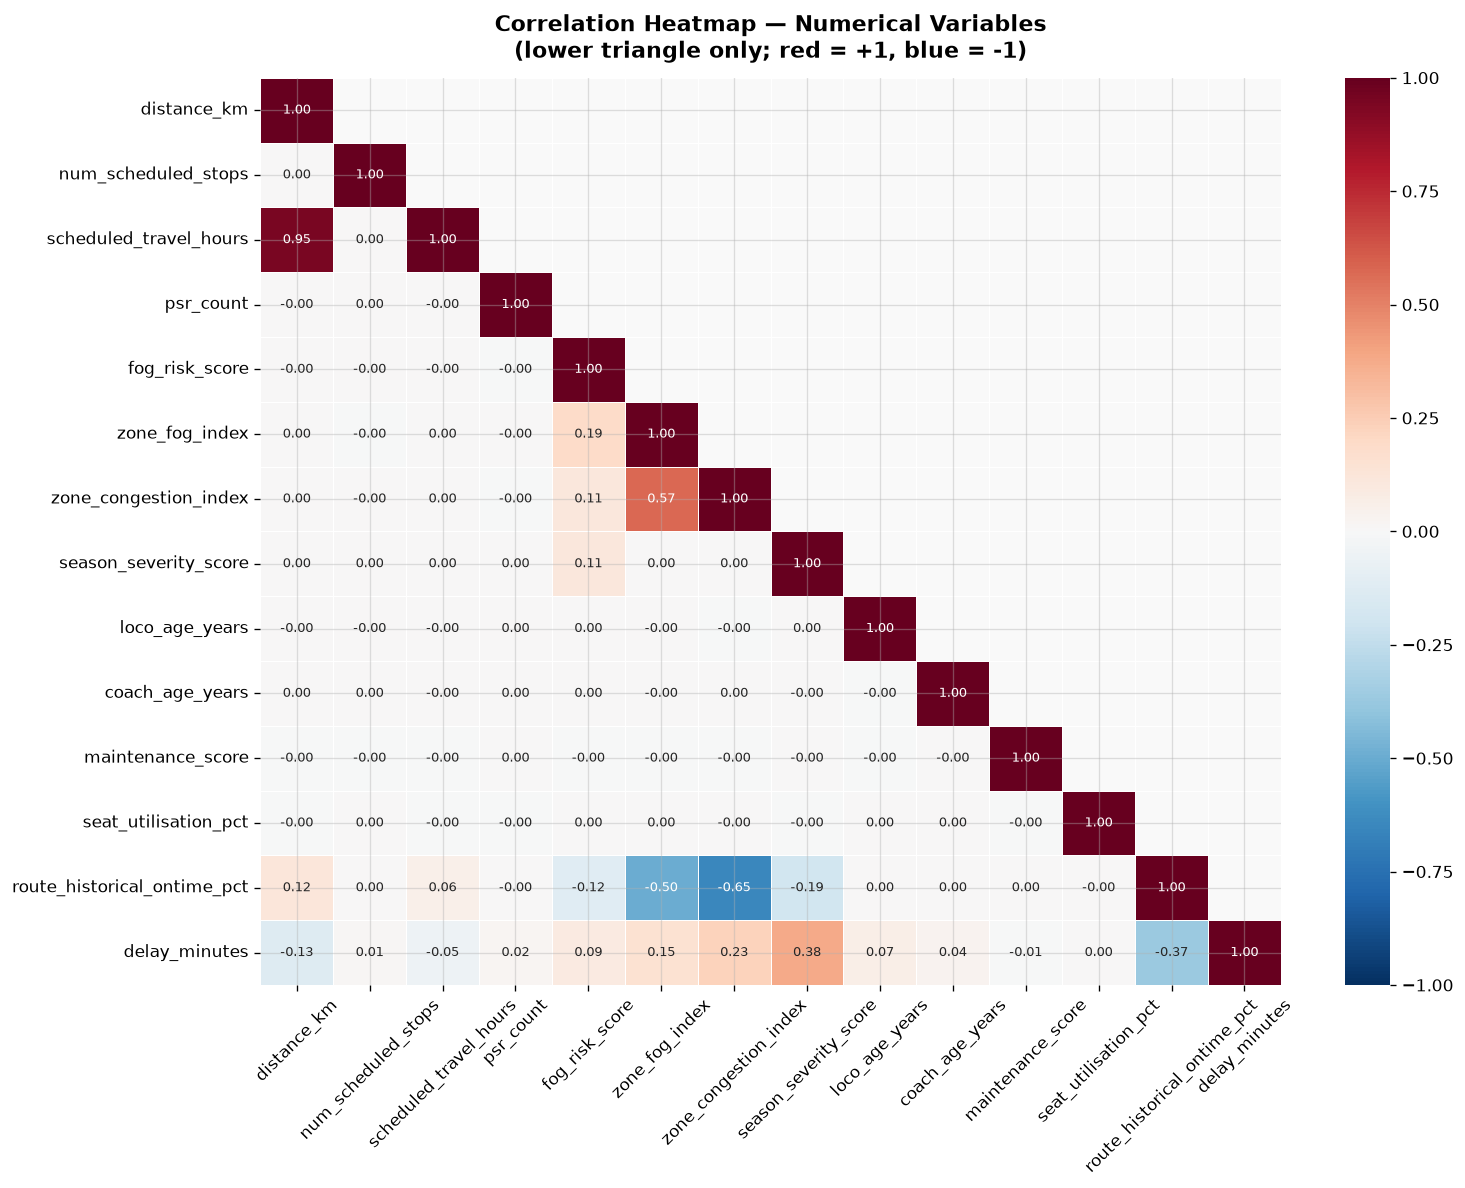

In [49]:
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
)
ax.set_title(
    'Correlation Heatmap — Numerical Variables\n'
    '(lower triangle only; red = +1, blue = -1)',
    fontsize=13, fontweight='bold', pad=12,
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
savefig('16_correlation_heatmap.png')
plt.show()

---
## Section 17 — Segment-Level Analysis

**Business Question:** Do meaningful cross-variable combinations reveal patterns hidden in single-variable EDA?

**Filter:** Only segments with ≥ 100 journeys are shown to avoid misleading small-sample conclusions.

In [50]:
def segment_delay_rate(col1, col2, min_count=100):
    """Pivot table of delay rate% for col1 x col2 cross-segment."""
    grp = (
        train.groupby([col1, col2], observed=True)
        .agg(total=('journey_id','count'), delayed=('is_delayed','sum'))
        .reset_index()
    )
    grp = grp[grp['total'] >= min_count]  # exclude small cells
    grp['delay_rate_pct'] = (grp['delayed'] / grp['total'] * 100).round(2)
    return grp.pivot(index=col1, columns=col2, values='delay_rate_pct')

print('=== Season x Train Type Delay Rate% ===')
print(segment_delay_rate('season', 'train_type').to_string())

=== Season x Train Type Delay Rate% ===
train_type    DEMU/MEMU  Duronto Express  Garib Rath Express  Gatimaan Express  Humsafar Express  Intercity Express  Jan Shatabdi Express  Mail/Express  Passenger Train  Rajdhani Express  Sampark Kranti Express  Shatabdi Express  Superfast Express  Tejas Express  Vande Bharat Express
season                                                                                                                                                                                                                                                                                      
Autumn            62.26            35.81               46.10             21.27             40.99              48.36                 38.29         60.43            75.54             30.43                   41.28             25.86              48.69          25.35                 18.83
Monsoon           97.16            88.54               92.48             78.38             90.95         

  -> Saved: ..\report\figures\eda\17_zone_traintype_heatmap.png


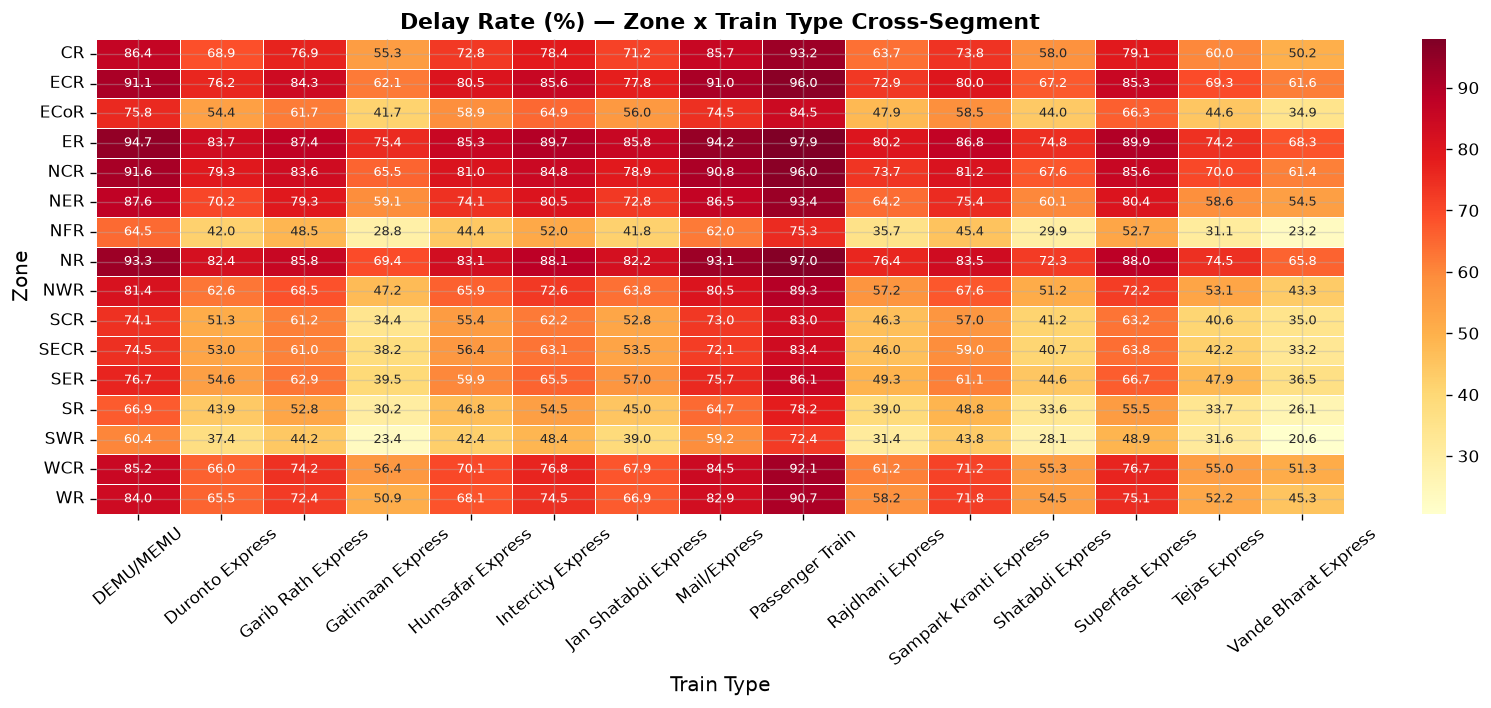

In [51]:
# Zone x Train Type heatmap
pivot_z_tt = segment_delay_rate('zone_abbr', 'train_type')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_z_tt, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white', ax=ax,
    annot_kws={'size': 8},
)
ax.set_title('Delay Rate (%) — Zone x Train Type Cross-Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Train Type')
ax.set_ylabel('Zone')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
savefig('17_zone_traintype_heatmap.png')
plt.show()

=== Monsoon x Zone Delay Rate% ===
zone_abbr             CR    ECR   ECoR     ER    NCR    NER    NFR     NR    NWR    SCR   SECR    SER     SR    SWR    WCR     WR
is_monsoon_season                                                                                                                
0                  69.34  78.12  53.36  84.51  78.29  71.41  38.95  82.02  62.03  50.46  50.93  54.62  41.60  34.89  67.34  64.80
1                  96.60  98.04  91.16  98.96  98.17  96.63  82.76  98.54  93.96  90.35  89.96  91.89  85.81  80.91  95.79  95.53



  -> Saved: ..\report\figures\eda\17_fog_zone_heatmap.png


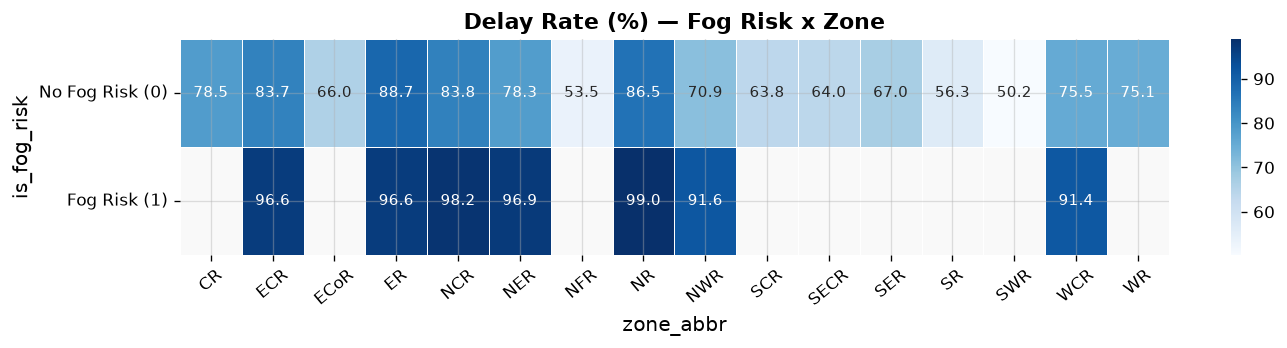

=== Peak Hour x Weekend Delay Rate% ===


is_weekend        0      1
is_peak_hour              
0             72.34  71.67
1             71.82  71.04


In [52]:
print('=== Monsoon x Zone Delay Rate% ===')
print(segment_delay_rate('is_monsoon_season', 'zone_abbr').to_string())
print()

# Fog Risk x Zone heatmap
pivot_fog_zone = segment_delay_rate('is_fog_risk', 'zone_abbr')
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    pivot_fog_zone, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.4, linecolor='white', ax=ax,
    annot_kws={'size': 9},
)
ax.set_title('Delay Rate (%) — Fog Risk x Zone', fontsize=13, fontweight='bold')
ax.set_yticklabels(['No Fog Risk (0)', 'Fog Risk (1)'], rotation=0)
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
savefig('17_fog_zone_heatmap.png')
plt.show()

print('=== Peak Hour x Weekend Delay Rate% ===')
print(segment_delay_rate('is_peak_hour', 'is_weekend').to_string())

---
## Section 18 — Outlier / Extreme Delay Analysis

**Business Question:** What characterizes the most severely delayed journeys?

**Note:** Extreme delays are NOT removed. A 579-minute delay can be a legitimate operational event.

In [53]:
top20 = train.nlargest(20, 'delay_minutes')[[
    'journey_id', 'train_number', 'train_type', 'zone_abbr',
    'delay_minutes', 'primary_delay_cause', 'is_fog_risk',
    'is_monsoon_season', 'late_incoming_rake', 'loco_age_years',
    'maintenance_score', 'departure_date',
]]
print('=== Top 20 Most Delayed Journeys ===')
print(top20.to_string(index=False))

=== Top 20 Most Delayed Journeys ===
journey_id train_number        train_type zone_abbr  delay_minutes     primary_delay_cause  is_fog_risk  is_monsoon_season  late_incoming_rake  loco_age_years  maintenance_score departure_date
IR00187536        11424      Mail/Express      ECoR            579 Track Maintenance / PSR            0                  1                   0            30.5                7.2     2022-06-05
IR01716000        11798      Mail/Express       NWR            567      Late Incoming Rake            0                  0                   1             8.9                5.4     2020-01-16
IR01726121        12274 Superfast Express       ECR            559      Late Incoming Rake            0                  0                   1             6.8                4.6     2023-03-11
IR01728373        51156   Passenger Train       SCR            540 Flooding / Waterlogging            0                  1                   1            14.1                7.6     2023-08-1

In [54]:
# Define 'extreme' as top 1% of delay_minutes among all journeys
threshold_99 = delayed['delay_minutes'].quantile(0.99)
extreme = train[train['delay_minutes'] >= threshold_99]
print(f'Extreme delay threshold (99th pct of delayed journeys): {threshold_99:.0f} min')
print(f'Extreme delay journey count: {len(extreme):,}')
print()
print('=== Train Type — Extreme Delays ===')
print(extreme['train_type'].value_counts())
print()
print('=== Zone — Extreme Delays ===')
print(extreme['zone_abbr'].value_counts())
print()
print('=== Primary Cause — Extreme Delays ===')
print(extreme['primary_delay_cause'].value_counts())
print()
print('=== Late Incoming Rake in Extreme Delays ===')
print(extreme['late_incoming_rake'].value_counts())

Extreme delay threshold (99th pct of delayed journeys): 265 min
Extreme delay journey count: 11,021

=== Train Type — Extreme Delays ===
train_type
Mail/Express              3584
DEMU/MEMU                 1838
Passenger Train           1545
Intercity Express         1198
Superfast Express         1001
Jan Shatabdi Express       423
Sampark Kranti Express     294
Garib Rath Express         246
Humsafar Express           220
Shatabdi Express           189
Duronto Express            154
Rajdhani Express           145
Vande Bharat Express       111
Tejas Express               43
Gatimaan Express            30
Name: count, dtype: int64

=== Zone — Extreme Delays ===
zone_abbr
ER      919
NCR     855
NR      844
ECR     820
NER     755
WR      753
CR      703
WCR     697
NWR     679
SER     648
ECoR    628
SECR    598
SR      591
SCR     580
NFR     481
SWR     470
Name: count, dtype: int64

=== Primary Cause — Extreme Delays ===
primary_delay_cause
Track Congestion           2508
Flooding /

  -> Saved: ..\report\figures\eda\18_extreme_delay_analysis.png


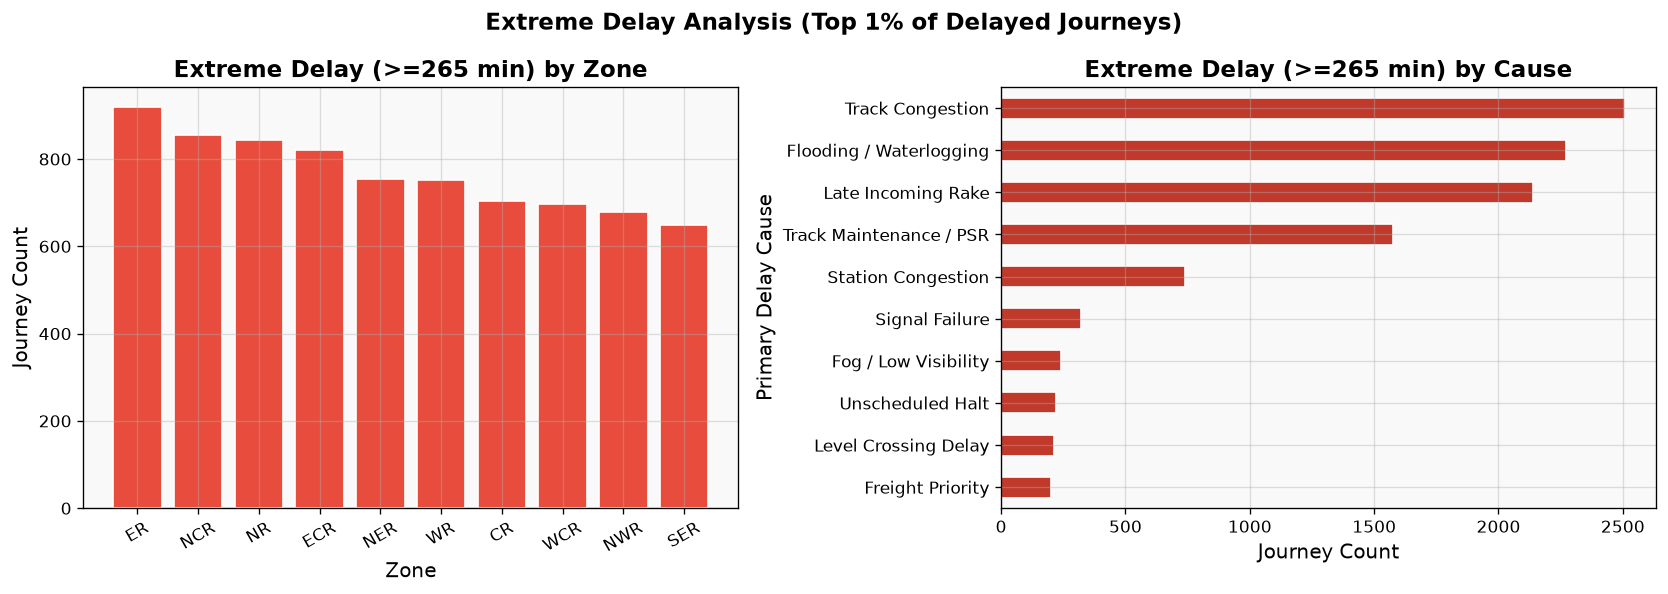

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ext_zone = extreme['zone_abbr'].value_counts().head(10)
axes[0].bar(ext_zone.index, ext_zone.values, color='#e74c3c', edgecolor='white')
axes[0].set_title(f'Extreme Delay (>={threshold_99:.0f} min) by Zone', fontweight='bold')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Journey Count')
axes[0].tick_params(axis='x', rotation=30)

ext_cause = extreme['primary_delay_cause'].value_counts().head(10)
ext_cause.sort_values().plot.barh(ax=axes[1], color='#c0392b', edgecolor='white')
axes[1].set_title(f'Extreme Delay (>={threshold_99:.0f} min) by Cause', fontweight='bold')
axes[1].set_xlabel('Journey Count')
axes[1].set_ylabel('Primary Delay Cause')

plt.suptitle('Extreme Delay Analysis (Top 1% of Delayed Journeys)', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('18_extreme_delay_analysis.png')
plt.show()

---
## Section 19 — Key EDA Findings

Each finding: **Observation | Supporting Metric | Business Interpretation**

> All findings are data-supported associations. No causal claims are made from EDA alone.

In [60]:
print('=' * 72)
print('  KEY EDA FINDINGS — RailInsight Phase 3')
print('=' * 72)

# F1
print(f"""
FINDING 1: High Base Delay Rate
  Observation  : {delayed_pct:.2f}% of all 1,500,000 journeys are delayed.
  Metric       : {delayed_count:,} delayed / {total:,} total journeys.
  Interpretation: A ~{delayed_pct:.0f}% overall delay rate suggests systemic operational
                  challenges. This is the primary metric requiring attention.
""")

# F2
med_d = delayed['delay_minutes'].median()
mean_d = delayed['delay_minutes'].mean()
q1 = delayed['delay_minutes'].quantile(0.25)
q3 = delayed['delay_minutes'].quantile(0.75)
print(f"""
FINDING 2: Consistent Moderate Delay Severity
  Observation  : Mean={mean_d:.1f} min, Median={med_d:.0f} min, IQR={q1:.0f}-{q3:.0f} min.
  Metric       : Tight IQR shows most delays cluster at 1.5-2.5 hours.
  Interpretation: This is a consistent operational pattern, not random noise.
""")

# F3
top_cause = cause_grp.iloc[0]
print(f"""
FINDING 3: Dominant Primary Delay Cause
  Observation  : '{top_cause['primary_delay_cause']}' covers {top_cause['pct_of_journeys']:.1f}% of all journeys.
  Metric       : {top_cause['journey_count']:,} journeys; avg delay = {top_cause['avg_delay']:.1f} min.
  Interpretation: This cause should be the primary target for operational mitigation.
""")

# F4
lr_data = flag_summary('late_incoming_rake')
lr_yes = lr_data[lr_data['late_incoming_rake'] == 1]['delay_rate_pct'].values[0]
lr_no  = lr_data[lr_data['late_incoming_rake'] == 0]['delay_rate_pct'].values[0]
print(f"""
FINDING 4: Late Incoming Rake Strongly Associated with Higher Delay Rate
  Observation  : Late rake => {lr_yes:.1f}% delay rate vs on-time rake => {lr_no:.1f}%.
  Metric       : Difference = +{lr_yes - lr_no:.1f} percentage points.
  Interpretation: Improved rake turnaround may reduce downstream delays.
                  (Association observed; causality not confirmed.)
""")

# F5
top_zone = zone_grp.iloc[0]
low_zone  = zone_grp.iloc[-1]
print(f"""
FINDING 5: Significant Zone-Level Variation
  Observation  : '{top_zone['zone_abbr']}' highest ({top_zone['delay_rate_pct']:.1f}%) vs '{low_zone['zone_abbr']}' lowest ({low_zone['delay_rate_pct']:.1f}%).
  Metric       : {top_zone['delay_rate_pct'] - low_zone['delay_rate_pct']:.1f} pp spread across zones.
  Interpretation: Geographic/operational differences appear zone-specific. High-congestion zones need monitoring.
""")

# F6
fog_d  = flag_summary('is_fog_risk')
fog_yes = fog_d[fog_d['is_fog_risk'] == 1]['delay_rate_pct'].values[0]
fog_no  = fog_d[fog_d['is_fog_risk'] == 0]['delay_rate_pct'].values[0]
print(f"""
FINDING 6: Fog Risk Associated with Elevated Delay Rate
  Observation  : Fog-risk journeys = {fog_yes:.1f}% vs non-fog = {fog_no:.1f}%.
  Metric       : Difference = +{fog_yes - fog_no:.1f} percentage points.
  Interpretation: Low-visibility conditions associated with slower operations.
""")

# F7
h_low  = hist_grp[hist_grp['hist_ontime_bin'] == '0-20%'] if 'hist_ontime_bin' not in train.columns else pd.DataFrame()
# hist_grp was computed in Section 14; re-compute briefly if not in scope:
train['_h_bin'] = pd.cut(train['route_historical_ontime_pct'],
                         bins=[0,20,40,60,80,100],
                         labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])
_hg = (
    train.groupby('_h_bin', observed=True)
    .agg(total=('journey_id','count'), delayed=('is_delayed','sum'))
    .reset_index()
)
_hg['delay_rate_pct'] = (_hg['delayed'] / _hg['total'] * 100).round(2)
train.drop(columns=['_h_bin'], inplace=True)
hl = _hg[_hg['_h_bin']=='0-20%']
hh = _hg[_hg['_h_bin']=='80-100%']
if not hl.empty and not hh.empty:
    print(f"""
FINDING 7: Historical Performance Predicts Current Delays
  Observation  : 0-20% historical on-time => {hl['delay_rate_pct'].values[0]:.1f}% current delay rate.
                 80-100% historical on-time => {hh['delay_rate_pct'].values[0]:.1f}% current delay rate.
  Interpretation: Persistent underperformers may need structural intervention, not just operational fixes.
""")

# F8
top_tt = tt.iloc[0]
low_tt  = tt.iloc[-1]
print(f"""
FINDING 8: Train Type Delay Rate Variation
  Observation  : '{top_tt['train_type']}' highest at {top_tt['delay_rate_pct']:.1f}% vs '{low_tt['train_type']}' lowest at {low_tt['delay_rate_pct']:.1f}%.
  Interpretation: Delay rate differences by type may reflect priority, route mix, or scheduling differences.
""")

# F9
print("""
FINDING 9: is_overloaded is a Constant Feature (Zero Analytical Value)
  Observation  : is_overloaded = 0 for all 1,500,000 records.
  Metric       : Variance = 0.0.
  Interpretation: Must be excluded from all downstream phases (SQL, Power BI, ML).
                  Revisit only if dataset is updated with actual overloading data.
""")

print('=' * 72)

  KEY EDA FINDINGS — RailInsight Phase 3

FINDING 1: High Base Delay Rate
  Observation  : 71.89% of all 1,500,000 journeys are delayed.
  Metric       : 1,078,329 delayed / 1,500,000 total journeys.
  Interpretation: A ~72% overall delay rate suggests systemic operational
                  challenges. This is the primary metric requiring attention.


FINDING 2: Consistent Moderate Delay Severity
  Observation  : Mean=133.2 min, Median=127 min, IQR=106-152 min.
  Metric       : Tight IQR shows most delays cluster at 1.5-2.5 hours.
  Interpretation: This is a consistent operational pattern, not random noise.


FINDING 3: Dominant Primary Delay Cause
  Observation  : 'On Time' covers 28.1% of all journeys.
  Metric       : 421,671 journeys; avg delay = 7.0 min.
  Interpretation: This cause should be the primary target for operational mitigation.


FINDING 4: Late Incoming Rake Strongly Associated with Higher Delay Rate
  Observation  : Late rake => 87.0% delay rate vs on-time rake => 63.

---
## Section 20 — Questions for Further Analysis

These questions are derived directly from EDA observations and should guide:
- **Phase 4 (SQL/PostgreSQL):** Data queries and aggregations
- **Phase 5 (Power BI):** Dashboard KPIs
- **Phase 7 (Optional ML):** Feature selection targets

In [61]:
questions = [
    ('OPERATIONAL',    'What proportion of delayed journeys had a late incoming rake, by zone and train type?'),
    ('OPERATIONAL',    'Which delay causes contribute most to TOTAL delay-minutes (count x avg delay)?'),
    ('GEOGRAPHIC',     'Which zones consistently rank top-3 in both delay rate AND severity?'),
    ('GEOGRAPHIC',     'In fog-risk zones, which months experience the worst delay spikes?'),
    ('TRAIN TYPE',     'Are certain train types more delay-prone regardless of zone or season?'),
    ('INFRASTRUCTURE', 'Does high PSR count + non-doubled track compound to predict higher delays?'),
    ('HISTORICAL',     'Do historically underperforming routes show improvement from 2018 to 2024?'),
    ('RISK PROFILE',   'What conditions are most common across the top-1% most delayed journeys?'),
    ('FLEET',          'Is there a loco/coach age threshold beyond which delays noticeably increase?'),
    ('CAPACITY',       'Does seat utilisation associate with higher delays, given is_overloaded is constant?'),
    ('TREND',          'Has average delay severity (minutes) per delayed journey changed 2018-2024?'),
    ('POWER BI',       'Which KPIs belong on an operational dashboard: zone delay rate, top causes, monthly trend?'),
]

print('=' * 72)
print('  RECOMMENDED QUESTIONS FOR PHASE 4 (SQL) AND PHASE 5 (POWER BI)')
print('=' * 72)
for i, (cat, q) in enumerate(questions, 1):
    print(f'\nQ{i:02d} [{cat}]')
    print(f'    {q}')
print()

  RECOMMENDED QUESTIONS FOR PHASE 4 (SQL) AND PHASE 5 (POWER BI)

Q01 [OPERATIONAL]
    What proportion of delayed journeys had a late incoming rake, by zone and train type?

Q02 [OPERATIONAL]
    Which delay causes contribute most to TOTAL delay-minutes (count x avg delay)?

Q03 [GEOGRAPHIC]
    Which zones consistently rank top-3 in both delay rate AND severity?

Q04 [GEOGRAPHIC]
    In fog-risk zones, which months experience the worst delay spikes?

Q05 [TRAIN TYPE]
    Are certain train types more delay-prone regardless of zone or season?

Q06 [INFRASTRUCTURE]
    Does high PSR count + non-doubled track compound to predict higher delays?

Q07 [HISTORICAL]
    Do historically underperforming routes show improvement from 2018 to 2024?

Q08 [RISK PROFILE]
    What conditions are most common across the top-1% most delayed journeys?

Q09 [FLEET]
    Is there a loco/coach age threshold beyond which delays noticeably increase?

Q10 [CAPACITY]
    Does seat utilisation associate with highe

In [62]:
sections_done = [
    '1. Post-Cleaning Dataset Overview',
    '2. Target / Delay Overview',
    '3. Day-of-Week Analysis',
    '4. Month and Seasonal Analysis',
    '5. Yearly Trend Analysis',
    '6. Departure Time Analysis',
    '7. Train Type Analysis',
    '8. Zone / Railway Zone Analysis',
    '9. Station Category Analysis',
    '10. Distance and Travel Duration',
    '11. Infrastructure / Route Characteristics',
    '12. Weather / Seasonal Risk',
    '13. Train Condition / Operational Factors',
    '14. Route Historical Performance',
    '15. Primary Delay Cause',
    '16. Correlation Analysis',
    '17. Segment-Level Analysis',
    '18. Outlier / Extreme Delay Analysis',
    '19. Key EDA Findings',
    '20. Questions for Further Analysis',
]
print('Phase 3 EDA — All sections complete.')
print(f'Figures directory: {os.path.abspath(FIG_DIR)}')
print()
for s in sections_done:
    print(f'  CHECK Section {s}')

Phase 3 EDA — All sections complete.
Figures directory: d:\Project\RailInsight\report\figures\eda

  CHECK Section 1. Post-Cleaning Dataset Overview
  CHECK Section 2. Target / Delay Overview
  CHECK Section 3. Day-of-Week Analysis
  CHECK Section 4. Month and Seasonal Analysis
  CHECK Section 5. Yearly Trend Analysis
  CHECK Section 6. Departure Time Analysis
  CHECK Section 7. Train Type Analysis
  CHECK Section 8. Zone / Railway Zone Analysis
  CHECK Section 9. Station Category Analysis
  CHECK Section 10. Distance and Travel Duration
  CHECK Section 11. Infrastructure / Route Characteristics
  CHECK Section 12. Weather / Seasonal Risk
  CHECK Section 13. Train Condition / Operational Factors
  CHECK Section 14. Route Historical Performance
  CHECK Section 15. Primary Delay Cause
  CHECK Section 16. Correlation Analysis
  CHECK Section 17. Segment-Level Analysis
  CHECK Section 18. Outlier / Extreme Delay Analysis
  CHECK Section 19. Key EDA Findings
  CHECK Section 20. Questions fo